# HW2: Regression and Classification -- Error Analysis
### Video Game Sales 2024 (VGChartz)

**Course:** Introduction to Data Science &nbsp;&nbsp;|&nbsp;&nbsp;

---

## Overview

This notebook continues the HW1 exploratory analysis of the *Video Game Sales 2024* dataset and moves
from description to **prediction and systematic error analysis**. Two supervised problems share one
feature set:

| Problem | Target | Type |
|---|---|---|
| Regression | `log1p(total_sales)` -- log global units sold (millions) | continuous |
| Classification | `is_hit` -- whether a title sold at least 1.0M units | binary, ~8% positive |

Every model is evaluated with **k-fold cross-validation**, and all analysis uses **out-of-fold
predictions**, so no observation is ever analysed by a model that saw it in training.
Part A covers data preparation and the choice of *k*; Part B the regression models (brief 2) and
regression error analysis (brief 1); Part C the classification error analysis (brief 3); Part D the
final reflection (brief 4).

**Requirements.** `pandas`, `numpy`, `scipy`, `matplotlib`, `seaborn` and **`scikit-learn >= 1.2`**
(`pip install scikit-learn` -- the only dependency beyond HW1). No external boosting library is
needed. `vgchartz-2024.csv` must sit in the same directory as this notebook.

## Part A -- Setup, Data Preparation and Cross-Validation Design

### A.1 Environment and global constants

In [101]:
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             precision_score, recall_score, f1_score, fbeta_score,
                             matthews_corrcoef, balanced_accuracy_score, brier_score_loss)
from sklearn.calibration import calibration_curve

# Silence only the known-benign third-party noise; anything unexpected still surfaces.
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*use_inf_as_na.*')

RANDOM_STATE = 42                 # single seed for every stochastic component
N_SPLITS = 5                      # number of cross-validation folds (justified in A.5)
HIT_THRESHOLD_MILLIONS = 1.0      # a title is a "hit" if it sold >= 1.0M units
REFERENCE_YEAR = 2024             # dataset snapshot year, used to derive game age
DATA_PATH = 'vgchartz-2024.csv'

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.labelsize': 10})
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

### A.2 Problem formulation and leakage control

**Target choice.** HW1 showed `total_sales` is extremely right-tailed (skewness 8.77, median 0.12M,
max 20.32M), so on the raw scale a handful of blockbusters would dominate a squared-error objective.
We model `log1p(total_sales)` -- monotonic, invertible, and far better behaved.

**Leakage control -- the critical decision.** `na_sales`, `jp_sales`, `pal_sales` and `other_sales`
are *components* of the target (HW1 verified they sum to it). Including them would give a
near-perfect $R^2$ that measures an accounting identity. **All four are excluded** from both tasks.

**Row filter.** Only rows with an observed `total_sales` and a parseable `release_date` are kept.
`total_sales` is missing for 70.4% of the catalogue, structurally rather than randomly (HW1), so the
modelling population is biased towards commercially tracked titles and every result is conditional
on that. `'Unknown'` in `publisher`/`developer` -- disguised nulls per HW1 -- is converted to `NaN`.

In [102]:
def load_modeling_frame(csv_path: str = DATA_PATH) -> pd.DataFrame:
    """Load vgchartz-2024, engineer features, and keep only rows with an observed target.

    Returns a frame that carries both supervised targets (`log_total_sales`, `is_hit`)
    alongside the raw columns needed for downstream error attribution.
    """
    raw = pd.read_csv(csv_path).drop_duplicates().reset_index(drop=True)

    # --- temporal features -------------------------------------------------
    raw['release_date'] = pd.to_datetime(raw['release_date'], format='%d/%m/%Y', errors='coerce')
    raw['release_year'] = raw['release_date'].dt.year
    raw['release_month'] = raw['release_date'].dt.month

    # --- cross-row feature: how many platforms did this title ship on? ------
    # Computed on the FULL catalogue (including rows without sales) because it
    # describes the release strategy, not the target.
    raw['platform_count'] = raw['title'].map(raw.groupby('title')['console'].nunique())

    # --- disguised nulls (identified in HW1) --------------------------------
    raw[['publisher', 'developer']] = raw[['publisher', 'developer']].replace('Unknown', np.nan)

    # --- supervised frame ---------------------------------------------------
    modeling = raw[raw['total_sales'].notna() & raw['release_year'].notna()].copy()
    modeling['release_year'] = modeling['release_year'].astype(int)
    modeling['game_age_years'] = REFERENCE_YEAR - modeling['release_year']
    modeling['has_critic_score'] = modeling['critic_score'].notna().astype(int)
    modeling['log_total_sales'] = np.log1p(modeling['total_sales'])
    modeling['is_hit'] = (modeling['total_sales'] >= HIT_THRESHOLD_MILLIONS).astype(int)
    return modeling.reset_index(drop=True)


games = load_modeling_frame()

print(f"Modeling frame: {games.shape[0]:,} rows x {games.shape[1]} columns")
print(f"Regression target  : log1p(total_sales)")
print(f"Classification target: is_hit (total_sales >= {HIT_THRESHOLD_MILLIONS}M) -- "
      f"{games['is_hit'].sum():,} positives ({games['is_hit'].mean():.2%})")
print(f"Release years covered: {games['release_year'].min()}-{games['release_year'].max()}")
print(f"critic_score missing within the modeling frame: {games['critic_score'].isna().mean():.1%}")

Modeling frame: 18,829 rows x 19 columns
Regression target  : log1p(total_sales)
Classification target: is_hit (total_sales >= 1.0M) -- 1,504 positives (7.99%)
Release years covered: 1977-2020
critic_score missing within the modeling frame: 78.1%


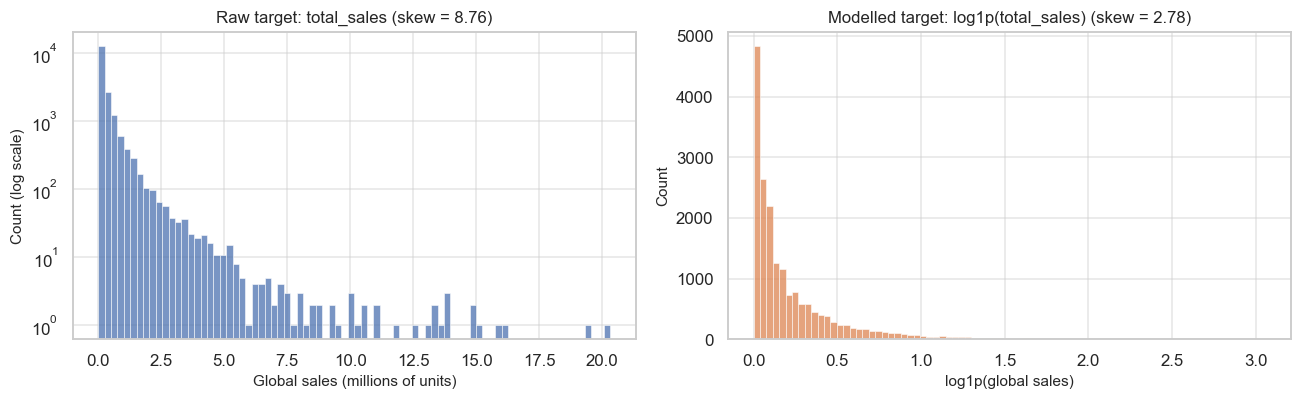

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

sns.histplot(games['total_sales'], bins=80, ax=axes[0], color='#4C72B0')
axes[0].set_yscale('log')
axes[0].set_title(f"Raw target: total_sales (skew = {stats.skew(games['total_sales']):.2f})")
axes[0].set_xlabel('Global sales (millions of units)')
axes[0].set_ylabel('Count (log scale)')

sns.histplot(games['log_total_sales'], bins=80, ax=axes[1], color='#DD8452')
axes[1].set_title(f"Modelled target: log1p(total_sales) (skew = {stats.skew(games['log_total_sales']):.2f})")
axes[1].set_xlabel('log1p(global sales)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Reading the transform.** The raw target needs a logarithmic *count* axis just to be visible --
the mass is crushed against zero with a tail reaching 20M units. `log1p` reduces skewness from
roughly 8.8 to well under 2 and produces a distribution a squared-error learner can work with.
The transform does not make the problem easy: as Part B shows, the residuals of the log-target model
are *still* right-skewed and heavy-tailed, because the underlying process is genuinely power-law.

### A.3 Feature set

All features are known *before* a title's sales are, so the setup is a legitimate forecasting problem:

| Family | Columns | Encoding |
|---|---|---|
| Numeric | `critic_score`, `release_year`, `release_month`, `game_age_years`, `platform_count`, `has_critic_score` | median imputation (+ standardisation where needed) |
| Low-cardinality categorical | `genre` (20), `console` (39) | one-hot, levels with < 30 rows folded into `infrequent` |
| High-cardinality categorical | `publisher` (739), `developer` (2,867), `console` | frequency encoding |

* **`has_critic_score` is a feature, not a nuisance.** 78.1% of the frame has no score, and HW1 showed
  that missingness is structured -- unreviewed titles are systematically smaller.
* **Frequency, not target, encoding** uses no information about `y`, so it cannot leak the target;
  target encoding would need nested CV to stay honest.
* **`game_age_years` is redundant by construction** (`2024 - release_year`, correlation -1.00). It is
  kept so the redundancy is visible in the B.3 diagnostics rather than hidden; trees are indifferent
  to it, but it is perfect collinearity for OLS.
* **`platform_count` caveat:** computed once over the whole catalogue, since it describes release
  strategy rather than the target. Not target leakage, but it does use rows that later land in test
  folds -- a mild optimism, noted again in B.6.

In [104]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Encode high-cardinality categoricals by their training-fold relative frequency.

    Categories never seen during `fit` are mapped to 0.0, which is the semantically
    correct signal for "this publisher/developer does not appear in the training data".
    Because the encoder is fitted inside the pipeline, it is refitted on every CV fold
    and cannot leak information across folds.
    """

    def fit(self, X: pd.DataFrame, y=None) -> 'FrequencyEncoder':
        self.feature_names_ = list(X.columns)
        self.frequency_maps_ = {col: X[col].value_counts(normalize=True) for col in X.columns}
        return self

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        return np.column_stack([
            X[col].map(self.frequency_maps_[col]).fillna(0.0).to_numpy()
            for col in self.feature_names_
        ])

    def get_feature_names_out(self, input_features=None) -> np.ndarray:
        return np.array([f'{col}_frequency' for col in self.feature_names_])


NUMERIC_FEATURES = ['critic_score', 'release_year', 'release_month',
                    'game_age_years', 'platform_count', 'has_critic_score']
ONE_HOT_FEATURES = ['genre', 'console']
FREQUENCY_FEATURES = ['publisher', 'developer', 'console']
MODEL_FEATURES = list(dict.fromkeys(NUMERIC_FEATURES + ONE_HOT_FEATURES + FREQUENCY_FEATURES))

LEAKY_COLUMNS = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
assert not set(MODEL_FEATURES) & set(LEAKY_COLUMNS), 'Regional sales must never enter the feature set'


def build_preprocessor(scale_numeric: bool = False) -> ColumnTransformer:
    """Preprocessing block; refitted inside every CV fold, so no cross-fold information leaks."""
    numeric_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), NUMERIC_FEATURES),
        ('one_hot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=30,
                                  sparse_output=False), ONE_HOT_FEATURES),
        ('frequency', FrequencyEncoder(), FREQUENCY_FEATURES),
    ])


def build_pipeline(model, scale_numeric: bool = False) -> Pipeline:
    return Pipeline([('preprocess', build_preprocessor(scale_numeric)), ('model', model)])


X = games[MODEL_FEATURES]
y_regression = games['log_total_sales'].to_numpy()
y_classification = games['is_hit'].to_numpy()

_n_encoded = build_preprocessor().fit_transform(X).shape[1]
print(f'Source feature columns : {len(MODEL_FEATURES)}')
print(f'Encoded design matrix  : {_n_encoded} columns')
print(f'Excluded as leakage    : {LEAKY_COLUMNS}')

Source feature columns : 10
Encoded design matrix  : 51 columns
Excluded as leakage    : ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']


### A.4 A single cross-validation engine

Every model in this notebook goes through the same function. It returns:

1. **out-of-fold (OOF) predictions** -- one prediction per row, always produced by a model that
   never saw that row. All error analysis in Parts B and C uses these, so the analysis reflects
   generalisation error rather than training-set memorisation;
2. **per-fold metrics** -- the spread across folds is itself a variance diagnostic.

In [105]:
def cross_validate_oof(pipeline, X, y, cv, task='regression'):
    """Run k-fold CV once and return (out-of-fold predictions, per-fold metric frame).

    For classification the OOF vector holds P(y = 1); for regression it holds y_hat.
    A single pass is used (rather than separate predict/score passes) so each fold is fitted once.
    """
    oof = np.zeros(len(y), dtype=float)
    fold_rows = []

    for fold_index, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        fitted = pipeline.fit(X.iloc[train_idx], y[train_idx])

        if task == 'regression':
            fold_pred = fitted.predict(X.iloc[test_idx])
            fold_rows.append({
                'fold': fold_index,
                'MAE': mean_absolute_error(y[test_idx], fold_pred),
                'RMSE': mean_squared_error(y[test_idx], fold_pred) ** 0.5,
                'R2': r2_score(y[test_idx], fold_pred),
            })
        else:
            fold_pred = fitted.predict_proba(X.iloc[test_idx])[:, 1]
            fold_rows.append({
                'fold': fold_index,
                'ROC_AUC': roc_auc_score(y[test_idx], fold_pred),
                'PR_AUC': average_precision_score(y[test_idx], fold_pred),
                'MCC': matthews_corrcoef(y[test_idx], (fold_pred >= 0.5).astype(int)),
            })

        oof[test_idx] = fold_pred

    return oof, pd.DataFrame(fold_rows).set_index('fold')

### A.5 Choice of *k* -- justification

**We use k = 5**, weighing dataset size, cost and the bias-variance trade-off:

1. **Dataset size.** ~18.8k rows means each fold holds out ~3.8k observations -- enough for the
   held-out *error distributions* this assignment analyses, not just point metrics. The top-5% error
   tail alone holds ~940 rows, which a larger *k* would make noisier.
2. **Bias-variance of the estimator.** Small *k* trains on 50-67% of the data and pessimistically
   biases the estimate; LOOCV has near-zero bias but high variance, since its training sets overlap
   almost completely. At 80% training data the bias is already small.
3. **Class imbalance.** With ~1,504 positives (8.0%), stratified 5-fold leaves ~300 per fold -- enough
   for a meaningful confusion matrix. At k = 10 that halves and per-fold precision gets noisy.
4. **Cost.** Ten models are evaluated, including an $O(n^2)$ SVR; k = 10 doubles runtime for a gain
   the check below shows to be negligible.

In [106]:
def evaluate_k_sensitivity(candidate_ks=(3, 5, 10)) -> pd.DataFrame:
    """Empirical support for the choice of k: mean and spread of R^2 across fold counts."""
    probe_model = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08,
                                                random_state=RANDOM_STATE)
    rows = []
    for k in candidate_ks:
        cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
        oof, folds = cross_validate_oof(build_pipeline(probe_model), X, y_regression, cv)
        rows.append({
            'k': k,
            'mean_fold_R2': folds['R2'].mean(),
            'std_fold_R2': folds['R2'].std(),
            'pooled_OOF_R2': r2_score(y_regression, oof),
            'pooled_OOF_RMSE': mean_squared_error(y_regression, oof) ** 0.5,
            'model_fits': k,
        })
    return pd.DataFrame(rows).set_index('k')


k_sensitivity = evaluate_k_sensitivity()
display(k_sensitivity.round(4))

,mean_fold_R2,std_fold_R2,pooled_OOF_R2,pooled_OOF_RMSE,model_fits
k,,,,,
3,0.5192,0.0152,0.5192,0.2185,3
5,0.5386,0.0179,0.5385,0.2141,5
10,0.5382,0.0228,0.5390,0.2140,10


**Result.** The pooled out-of-fold $R^2$ rises by about **0.019 from k = 3 to k = 5** -- the
pessimistic bias of training on only 67% of the data -- and then by a further **0.0005 from k = 5 to
k = 10**, i.e. essentially nothing for double the compute. Meanwhile the *standard deviation across
folds* grows monotonically (0.015 -> 0.018 -> 0.023): exactly the variance inflation theory predicts,
because larger *k* means smaller, noisier test folds. k = 5 is therefore the point where the bias has
been paid off but fold-level estimates are still stable. **k = 5 is used for every experiment from here on**, with
`StratifiedKFold` for the classification task so that the 8% positive rate is preserved in each fold.

In [107]:
REGRESSION_CV = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
CLASSIFICATION_CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

---

## Part B -- Regression

Sections 1 and 2 of the brief are presented in reverse order: the models are fitted first
(brief section 2), because the error analysis (brief section 1) needs their out-of-fold predictions.

### B.1 Models and hyperparameters

Six models are compared. All three required families are present, plus both optional bonus models.
Every model receives **exactly the same feature set** and the same folds, so the comparison isolates
the effect of the modelling assumption rather than of the inputs.

In [108]:
@dataclass
class ModelSpec:
    """A model together with the preprocessing variant it requires."""
    estimator: object
    scale_numeric: bool
    family: str
    hyperparameters: str


REGRESSION_MODELS = {
    'Linear Regression': ModelSpec(
        LinearRegression(), True, 'Linear (baseline)',
        'default (OLS, no regularisation); numeric features standardised'),
    'Decision Tree': ModelSpec(
        DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=RANDOM_STATE),
        False, 'Single tree', 'max_depth=8, min_samples_leaf=20'),
    'Random Forest': ModelSpec(
        RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                              n_jobs=-1, random_state=RANDOM_STATE),
        False, 'Bagging ensemble', 'n_estimators=300, min_samples_leaf=2'),
    'Gradient Boosting': ModelSpec(
        HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, random_state=RANDOM_STATE),
        False, 'Boosting ensemble', 'max_iter=400, learning_rate=0.06'),
    'KNN (bonus)': ModelSpec(
        KNeighborsRegressor(n_neighbors=15, weights='distance', n_jobs=-1),
        True, 'Instance-based', 'n_neighbors=15, weights="distance"; features standardised'),
    'SVR (bonus)': ModelSpec(
        SVR(C=1.0, epsilon=0.05, cache_size=1000), True, 'Kernel method',
        'RBF kernel, C=1.0, epsilon=0.05; features standardised'),
}

display(pd.DataFrame(
    [{'Model': name, 'Family': spec.family, 'Hyperparameters': spec.hyperparameters}
     for name, spec in REGRESSION_MODELS.items()]).set_index('Model'))

,Family,Hyperparameters
Model,,
Linear Regression,Linear (baseline),"default (OLS, no regularisation); numeric feat..."
Decision Tree,Single tree,"max_depth=8, min_samples_leaf=20"
Random Forest,Bagging ensemble,"n_estimators=300, min_samples_leaf=2"
Gradient Boosting,Boosting ensemble,"max_iter=400, learning_rate=0.06"
KNN (bonus),Instance-based,"n_neighbors=15, weights=""distance""; features s..."
SVR (bonus),Kernel method,"RBF kernel, C=1.0, epsilon=0.05; features stan..."


**Hyperparameter policy.** Values are lightly chosen rather than exhaustively tuned, and are stated
explicitly above. The tree depth and leaf-size constraints are deliberate: an unconstrained tree on
19k rows memorises the training fold and produces error diagnostics that describe overfitting rather
than the structure of the problem. Tuning every model by nested search would improve absolute scores
but would not change the *error structure* this assignment is about -- and the discussion in B.7
returns to what tuning could and could not fix.

In [76]:
regression_oof = {}
regression_fold_metrics = {}
regression_summary_rows = []

for name, spec in REGRESSION_MODELS.items():
    pipeline = build_pipeline(spec.estimator, spec.scale_numeric)
    oof, folds = cross_validate_oof(pipeline, X, y_regression, REGRESSION_CV, task='regression')
    residuals = y_regression - oof

    regression_oof[name] = oof
    regression_fold_metrics[name] = folds
    regression_summary_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_regression, oof),
        'MSE': mean_squared_error(y_regression, oof),
        'RMSE': mean_squared_error(y_regression, oof) ** 0.5,
        'R2': r2_score(y_regression, oof),
        'RMSE_fold_std': folds['RMSE'].std(),
        'R2_fold_std': folds['R2'].std(),
    })
    print(f'{name:<20s} done')

regression_summary = pd.DataFrame(regression_summary_rows).set_index('Model')
display(regression_summary.round(4))

Linear Regression    done
Decision Tree        done
Random Forest        done
Gradient Boosting    done
KNN (bonus)          done
SVR (bonus)          done


,MAE,MSE,RMSE,R2,RMSE_fold_std,R2_fold_std
Model,,,,,,
Linear Regression,0.1725,0.0678,0.2604,0.3170,0.0058,0.0169
Decision Tree,0.1595,0.0644,0.2538,0.3513,0.0055,0.0135
Random Forest,0.1350,0.0469,0.2166,0.5276,0.0047,0.0148
Gradient Boosting,0.1344,0.0451,0.2124,0.5455,0.0062,0.0218
KNN (bonus),0.1596,0.0621,0.2491,0.3749,0.0053,0.0154
SVR (bonus),0.1424,0.0580,0.2409,0.4156,0.0075,0.0245


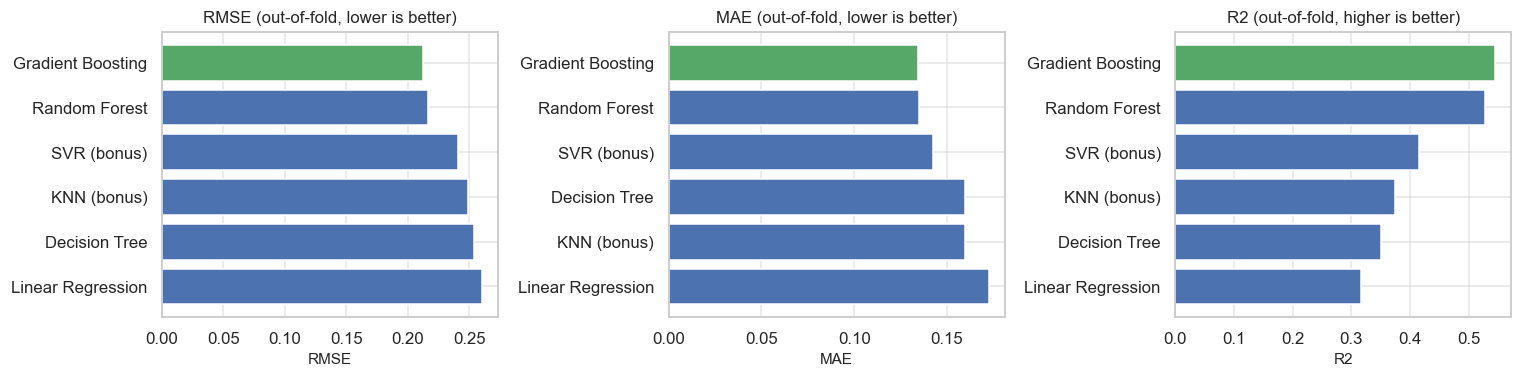

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, metric, better in zip(axes, ['RMSE', 'MAE', 'R2'], ['lower', 'lower', 'higher']):
    ordered = regression_summary[metric].sort_values(ascending=(better == 'lower'))
    colors = ['#55A868' if v == (ordered.min() if better == 'lower' else ordered.max())
              else '#4C72B0' for v in ordered]
    ax.barh(ordered.index, ordered.values, color=colors)
    ax.set_title(f'{metric} (out-of-fold, {better} is better)')
    ax.set_xlabel(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Relative performance.** The ranking is consistent across all three metrics: Gradient Boosting
($R^2 \approx 0.55$) ≳ Random Forest ($0.53$) > SVR ($0.42$) > KNN ($0.37$) > Decision Tree ($0.35$)
> Linear Regression ($0.32$). The largest single jump is from one tree to 300 of them (+0.18 $R^2$):
the signal is not a smooth function of the features but a mass of local, interacting rules (this
publisher, on that console, in that year). KNN and SVR sit in the middle -- both capture
non-linearity, but a ~100-column, mostly one-hot design matrix makes Euclidean distance a poor notion
of similarity.

The `RMSE_fold_std` column shows how far to trust this ranking, and it does **not** support every
comparison equally. Fold noise is ~0.005-0.008 RMSE, so gaps between families are real (Linear
Regression trails Gradient Boosting by 0.048, roughly eight fold-standard-deviations). But Random
Forest and Gradient Boosting differ by only **0.0042**, less than either model's own fold spread:
**this experiment does not separate them on accuracy.** B.7 therefore treats them as tied and
distinguishes them on error structure instead.

### B.2 Residual analysis (brief 1.1)

All diagnostics from here on use the best model, **Gradient Boosting**, on its out-of-fold
predictions. Residuals are defined as in the brief:

$$\text{Residual} = y - \hat{y}$$

on the log scale, where $y = \log(1 + \text{total\_sales})$.

In [78]:
BEST_REGRESSOR = regression_summary['RMSE'].idxmin()
print(f'Best regression model by out-of-fold RMSE: {BEST_REGRESSOR}')

predicted = regression_oof[BEST_REGRESSOR]
residuals = y_regression - predicted
absolute_errors = np.abs(residuals)

error_frame = games.assign(
    predicted_log=predicted,
    residual=residuals,
    absolute_error=absolute_errors,
    predicted_sales=np.expm1(predicted),
)

Best regression model by out-of-fold RMSE: Gradient Boosting


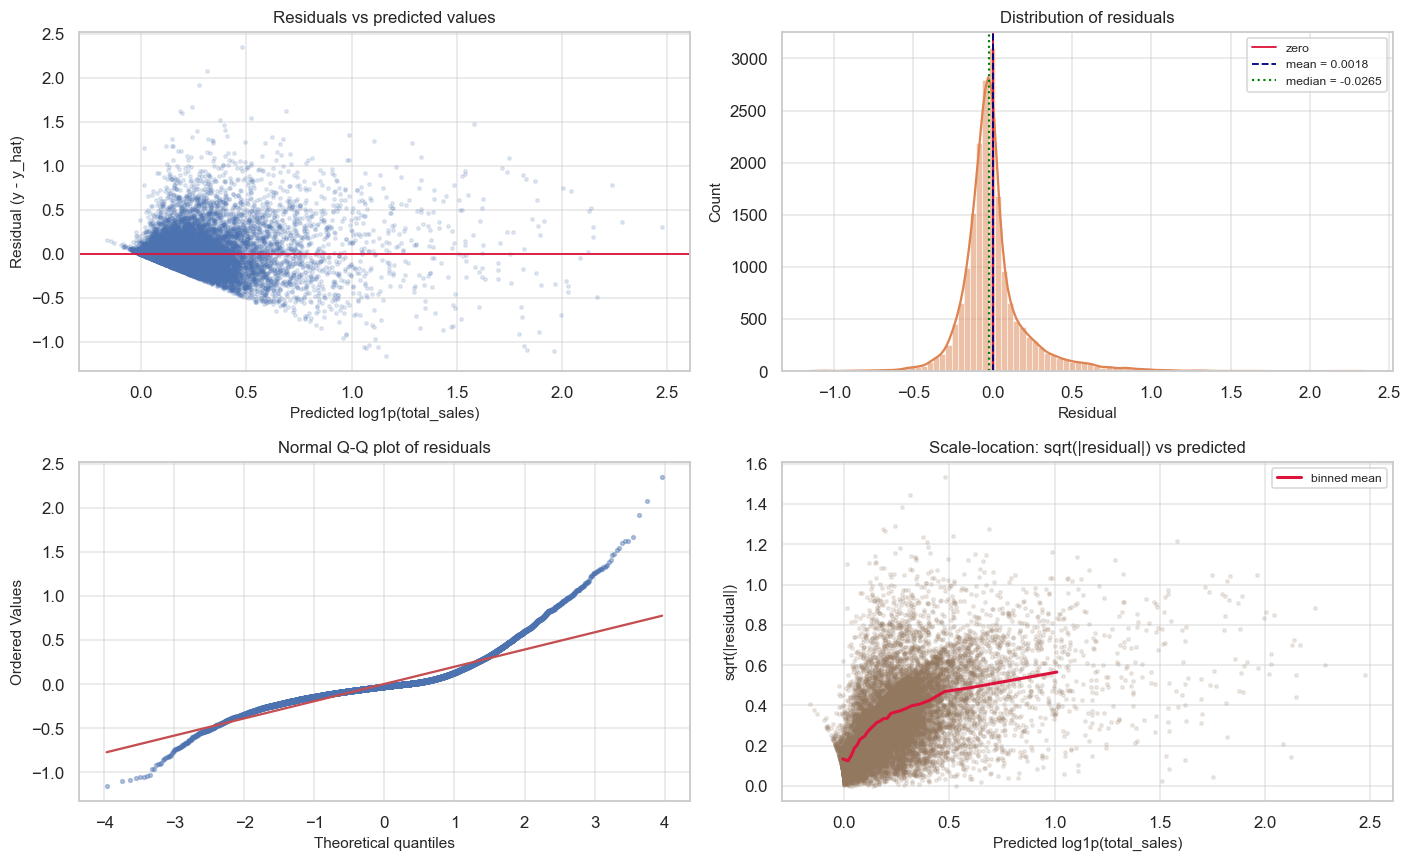

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) Residuals vs predicted values
axes[0, 0].scatter(predicted, residuals, s=5, alpha=0.15, color='#4C72B0')
axes[0, 0].axhline(0, color='crimson', lw=1.2)
axes[0, 0].set_title('Residuals vs predicted values')
axes[0, 0].set_xlabel('Predicted log1p(total_sales)')
axes[0, 0].set_ylabel('Residual (y - y_hat)')

# (2) Distribution of residuals
sns.histplot(residuals, bins=90, kde=True, ax=axes[0, 1], color='#DD8452')
axes[0, 1].axvline(0, color='crimson', lw=1.2, label='zero')
axes[0, 1].axvline(residuals.mean(), color='navy', ls='--', lw=1.2,
                   label=f'mean = {residuals.mean():.4f}')
axes[0, 1].axvline(np.median(residuals), color='green', ls=':', lw=1.4,
                   label=f'median = {np.median(residuals):.4f}')
axes[0, 1].set_title('Distribution of residuals')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].legend(fontsize=8)

# (3) Normal Q-Q plot -- tail behaviour
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q plot of residuals')
axes[1, 0].get_lines()[0].set_markersize(2.5)
axes[1, 0].get_lines()[0].set_alpha(0.4)

# (4) Scale-location plot -- variance as a function of the fitted value
axes[1, 1].scatter(predicted, np.sqrt(absolute_errors), s=5, alpha=0.15, color='#937860')
binned = pd.DataFrame({'p': predicted, 's': np.sqrt(absolute_errors)})
binned['bin'] = pd.qcut(binned['p'], 25, labels=False)
trend = binned.groupby('bin').agg(p=('p', 'mean'), s=('s', 'mean'))
axes[1, 1].plot(trend['p'], trend['s'], color='crimson', lw=2, label='binned mean')
axes[1, 1].set_title('Scale-location: sqrt(|residual|) vs predicted')
axes[1, 1].set_xlabel('Predicted log1p(total_sales)')
axes[1, 1].set_ylabel('sqrt(|residual|)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [80]:
# --- Quantitative backing for the four questions in brief 1.1 ---------------
centering_test = stats.ttest_1samp(residuals, 0.0)
heteroscedasticity_test = stats.spearmanr(absolute_errors, predicted)

print('Is the residual mean zero?')
print(f'  mean   = {residuals.mean(): .5f}   median = {np.median(residuals): .5f}')
print(f'  one-sample t-test H0: mean = 0  ->  t = {centering_test.statistic:.3f}, '
      f'p = {centering_test.pvalue:.4f}')
print()
print('Is the residual spread constant?')
print(f'  Spearman corr(|residual|, predicted) = {heteroscedasticity_test.statistic:.4f} '
      f'(p = {heteroscedasticity_test.pvalue:.2e})')
print()

decile_profile = (error_frame
    .assign(prediction_decile=pd.qcut(predicted, 10, labels=False) + 1)
    .groupby('prediction_decile')
    .agg(n=('residual', 'size'),
         mean_predicted=('predicted_log', 'mean'),
         mean_residual=('residual', 'mean'),
         residual_std=('residual', 'std'),
         MAE=('absolute_error', 'mean')))
print('Residual behaviour by decile of the predicted value:')
display(decile_profile.round(4))

Is the residual mean zero?
  mean   =  0.00179   median = -0.02648
  one-sample t-test H0: mean = 0  ->  t = 1.154, p = 0.2485

Is the residual spread constant?
  Spearman corr(|residual|, predicted) = 0.6171 (p = 0.00e+00)

Residual behaviour by decile of the predicted value:


,n,mean_predicted,mean_residual,residual_std,MAE
prediction_decile,,,,,
1,1883,0.0113,0.0145,0.0553,0.0252
2,1883,0.0525,0.0018,0.0722,0.0446
3,1883,0.0829,-0.0031,0.1005,0.0667
4,1883,0.1149,-0.0052,0.1309,0.0889
5,1883,0.1514,-0.0035,0.1719,0.1160
6,1882,0.1915,-0.0007,0.1886,0.1330
7,1883,0.2385,-0.0071,0.2122,0.1564
8,1883,0.2998,0.0019,0.2487,0.1819
9,1883,0.3969,-0.0050,0.2834,0.2146


#### Answers to the questions in brief 1.1

**Centred around zero?** On average yes -- mean residual ~0.002, and a t-test cannot reject
$H_0: \mathbb{E}[r]=0$ (p ≈ 0.25). But the *median* is **-0.026**. Mean ≈ 0 with median < 0 is the
signature of a **right-skewed** error distribution: the model slightly over-predicts the typical game,
offset by a minority of very large under-predictions. Global unbiasedness hides a systematic pattern.

**Systematic patterns?** Yes. Mean residuals are mildly negative through deciles 2-8 and turn
**positive (+0.024) in the top decile** -- the model under-predicts the games it already expects to
sell well. This is **regression toward the mean**: a squared-error learner hedges towards the
conditional average, which in a power-law market sits far below a blockbuster's outcome. The
residuals-vs-predicted panel shows it geometrically, with a hard diagonal floor on the lower left
(a zero-sales game gives exactly `residual = -prediction`) and a plume of positive residuals right.

**Heteroscedasticity?** Strongly. Residual standard deviation rises from **0.055 in the lowest
predicted decile to 0.403 in the highest**, and Spearman's $\rho(|r|, \hat{y}) = 0.617$. This violates
OLS homoskedasticity, so its standard errors and any interval from them are untrustworthy. It also has
a benign reading: `log1p` compresses the tail but cannot remove the fact that uncertainty grows with
commercial scale.

**A sector with high error rates?** Yes -- the **mainstream, multi-platform, critically reviewed,
Western-console blockbuster** segment, examined in B.3. The low-error sector is the niche long tail.
The mechanism is the heteroscedasticity above: error scales with target magnitude.

### B.3 Error as a function of the features (brief 1.2)

The brief asks for feature values plotted against both signed residuals and absolute errors, to
surface non-linear relationships, feature-dependent error patterns and hidden subpopulations.

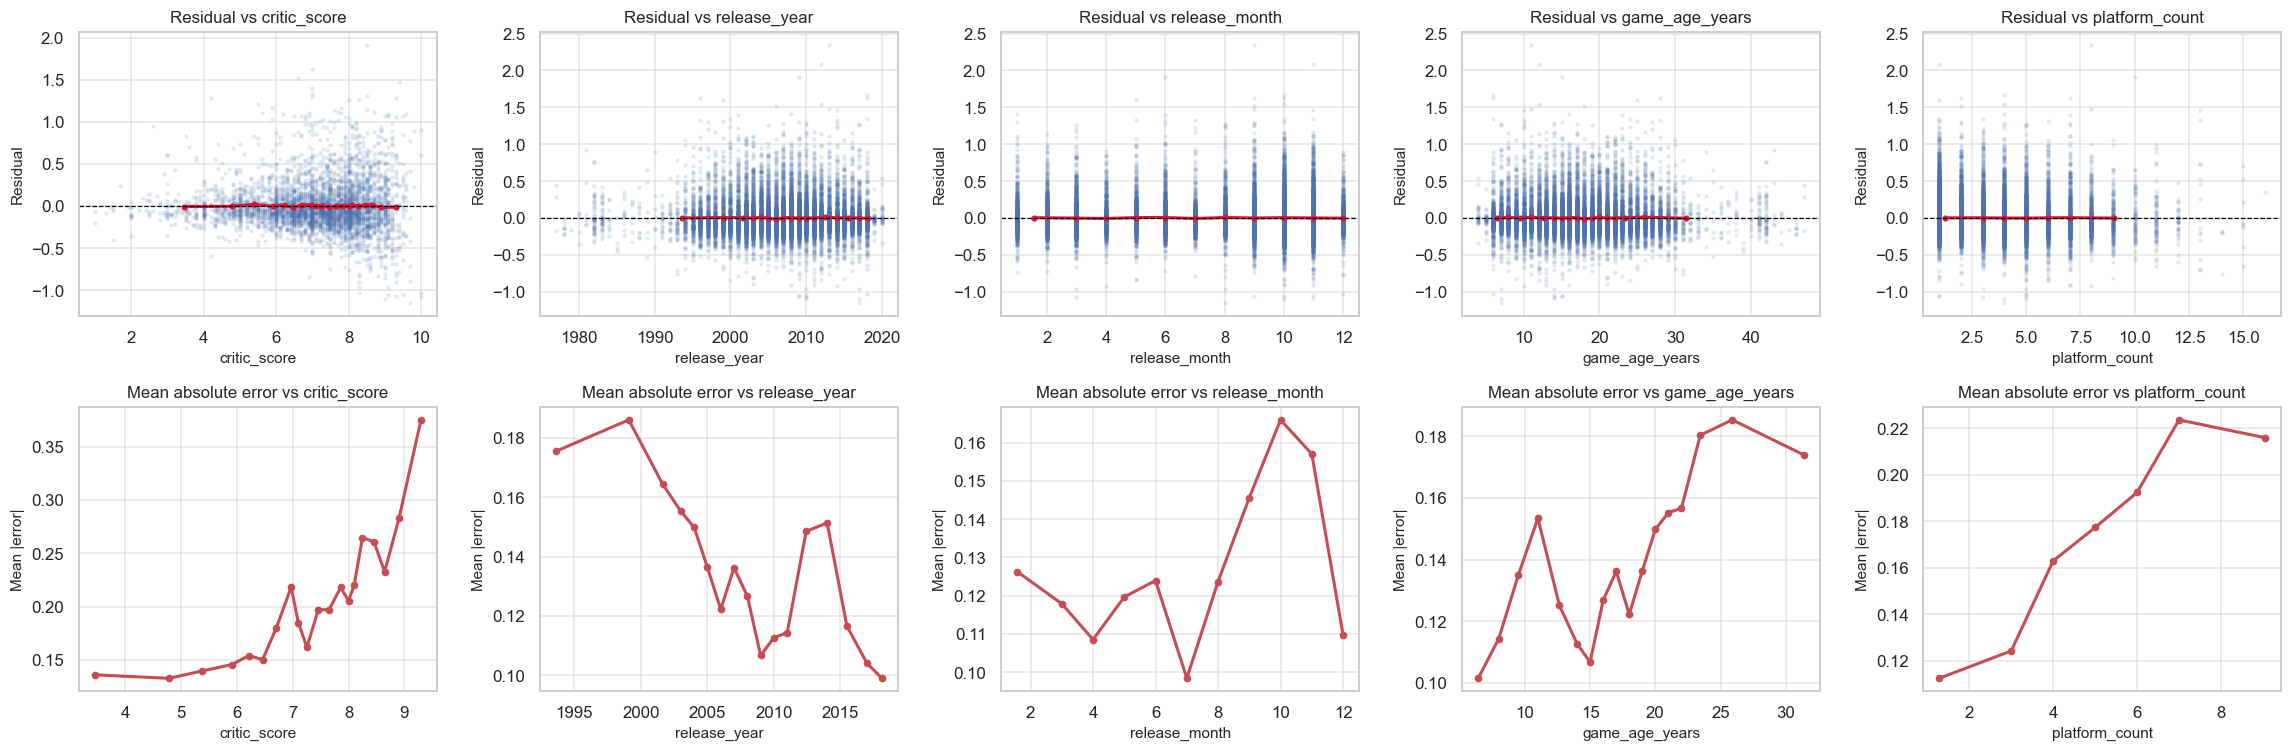

feature_mean     MAE
feature        quintile                      
critic_score   0.0             4.9236  0.1389
               1.0             6.6350  0.1802
               2.0             7.4188  0.1863
               3.0             8.0484  0.2294
               4.0             8.8257  0.2894
release_year   0.0          1999.3332  0.1706
               1.0          2005.6871  0.1353
               2.0          2008.5189  0.1164
               3.0          2011.0888  0.1245
               4.0          2016.0990  0.1168
release_month  0.0             2.2261  0.1225
               1.0             5.1121  0.1182
               2.0             8.2722  0.1289
               3.0            10.5137  0.1614
               4.0            12.0000  0.1098
game_age_years 0.0             8.3193  0.1217
               1.0            13.8254  0.1154
               2.0            16.4383  0.1309
               3.0            19.3794  0.1395
               4.0            25.5457  0.1743
platform_count 0.0             1.6197  0.1148
               1.0             4.0000  0.1630
               2.0             6.4792  0.1972

month,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
n,929.0000,1232.0000,1832.0000,1040.0000,1105.0000,1442.000,952.0000,1248.0000,2131.0000,2826.000,2985.0000,1107.0000
MAE,0.1341,0.1205,0.1179,0.1085,0.1197,0.124,0.0984,0.1237,0.1457,0.166,0.1571,0.1098


In [81]:
def plot_error_against_feature(ax_signed, ax_absolute, feature, n_bins=20):
    """Scatter + binned-mean view of residual and |error| against one numeric feature."""
    subset = error_frame[[feature, 'residual', 'absolute_error']].dropna()
    binned = subset.assign(bin=pd.qcut(subset[feature], n_bins, labels=False, duplicates='drop'))
    trend = binned.groupby('bin').agg(x=(feature, 'mean'),
                                      residual=('residual', 'mean'),
                                      absolute_error=('absolute_error', 'mean'))

    ax_signed.scatter(subset[feature], subset['residual'], s=4, alpha=0.10, color='#4C72B0')
    ax_signed.plot(trend['x'], trend['residual'], color='crimson', lw=2, marker='o', ms=3)
    ax_signed.axhline(0, color='black', lw=0.8, ls='--')
    ax_signed.set_xlabel(feature)
    ax_signed.set_ylabel('Residual')
    ax_signed.set_title(f'Residual vs {feature}')

    ax_absolute.plot(trend['x'], trend['absolute_error'], color='#C44E52', lw=2, marker='o', ms=4)
    ax_absolute.set_xlabel(feature)
    ax_absolute.set_ylabel('Mean |error|')
    ax_absolute.set_title(f'Mean absolute error vs {feature}')


# Every numeric feature is probed, not a selected subset.
numeric_features_to_probe = ['critic_score', 'release_year', 'release_month',
                             'game_age_years', 'platform_count']
fig, axes = plt.subplots(2, len(numeric_features_to_probe), figsize=(21, 7))
for column, feature in enumerate(numeric_features_to_probe):
    plot_error_against_feature(axes[0, column], axes[1, column], feature)
plt.tight_layout()
plt.show()

# Binned mean |error| per feature, so the trends above can be read as numbers.
feature_error_table = pd.concat(
    {feature: (error_frame
               .assign(decile=pd.qcut(error_frame[feature], 5, labels=False, duplicates='drop'))
               .groupby('decile')
               .agg(feature_mean=(feature, 'mean'), MAE=('absolute_error', 'mean')))
     for feature in numeric_features_to_probe},
    names=['feature', 'quintile'])
display(feature_error_table.round(4))

# release_month is seasonal rather than ordinal, so it is also shown month by month.
monthly_error = (error_frame.groupby('release_month')
                 .agg(n=('absolute_error', 'size'), MAE=('absolute_error', 'mean'))
                 .rename_axis('month'))
display(monthly_error.round(4).T)

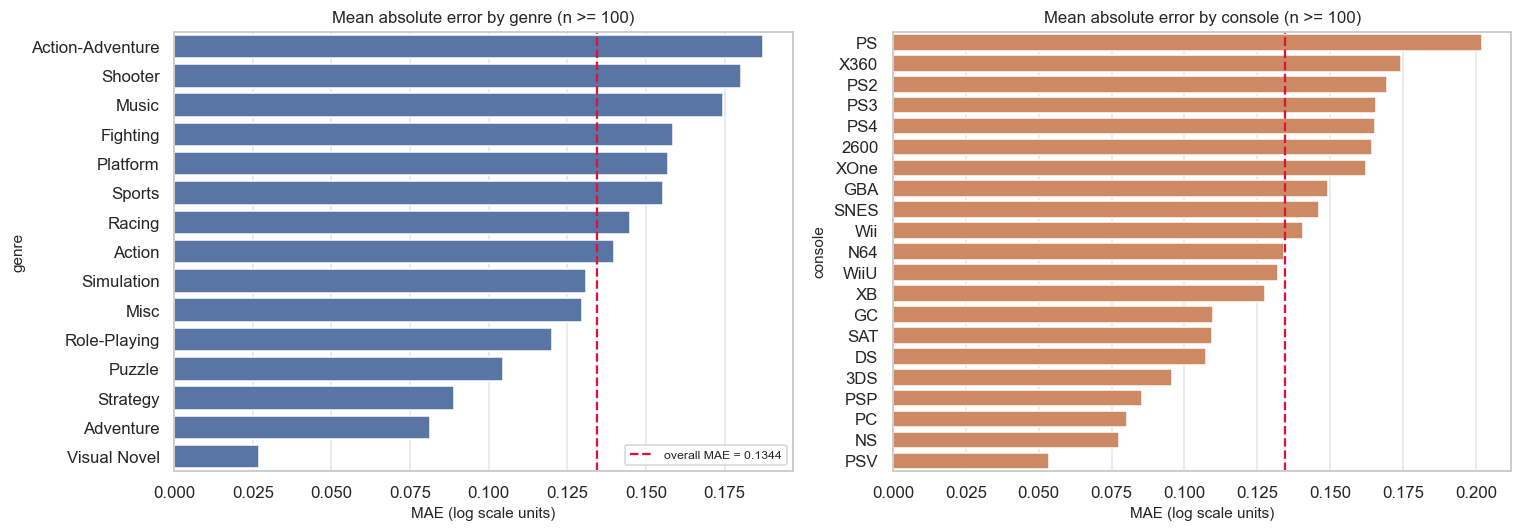

,n,MAE,mean_residual,mean_actual_sales
genre,,,,
Action-Adventure,264,0.1873,-0.0068,0.5626
Shooter,1480,0.1801,0.0008,0.6726
Music,147,0.1746,-0.0101,0.3520
Fighting,867,0.1584,0.0054,0.3926
Platform,949,0.1571,-0.0023,0.3679
Sports,2580,0.1555,0.0030,0.4600
Racing,1422,0.1450,0.0013,0.3682
Action,2825,0.1397,0.0054,0.3982
Simulation,1116,0.1311,0.0065,0.2692


In [82]:
def error_profile_by_category(column, min_count=100):
    """Mean |error| and mean signed residual per category level."""
    return (error_frame
            .groupby(column)
            .agg(n=('absolute_error', 'size'),
                 MAE=('absolute_error', 'mean'),
                 mean_residual=('residual', 'mean'),
                 mean_actual_sales=('total_sales', 'mean'))
            .query('n >= @min_count')
            .sort_values('MAE', ascending=False))


genre_errors = error_profile_by_category('genre')
console_errors = error_profile_by_category('console')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=genre_errors['MAE'], y=genre_errors.index, ax=axes[0], color='#4C72B0')
axes[0].axvline(absolute_errors.mean(), color='crimson', ls='--',
                label=f'overall MAE = {absolute_errors.mean():.4f}')
axes[0].set_title('Mean absolute error by genre (n >= 100)')
axes[0].set_xlabel('MAE (log scale units)')
axes[0].legend(fontsize=8)

sns.barplot(x=console_errors['MAE'], y=console_errors.index, ax=axes[1], color='#DD8452')
axes[1].axvline(absolute_errors.mean(), color='crimson', ls='--')
axes[1].set_title('Mean absolute error by console (n >= 100)')
axes[1].set_xlabel('MAE (log scale units)')

plt.tight_layout()
plt.show()

display(genre_errors.round(4))

In [83]:
# Two hidden subpopulations surfaced by the plots above
critic_split = (error_frame.groupby('has_critic_score')
                .agg(n=('absolute_error', 'size'),
                     MAE=('absolute_error', 'mean'),
                     mean_actual_sales=('total_sales', 'mean'),
                     hit_rate=('is_hit', 'mean')))
critic_split.index = ['No critic score', 'Has critic score']

platform_split = (error_frame
                  .assign(platforms=error_frame['platform_count'].clip(upper=6))
                  .groupby('platforms')
                  .agg(n=('absolute_error', 'size'),
                       MAE=('absolute_error', 'mean'),
                       mean_actual_sales=('total_sales', 'mean')))

era_split = (error_frame
             .assign(era=pd.cut(error_frame['release_year'],
                                [1976, 1995, 2000, 2005, 2010, 2015, 2021]))
             .groupby('era', observed=True)
             .agg(n=('absolute_error', 'size'),
                  MAE=('absolute_error', 'mean'),
                  mean_actual_sales=('total_sales', 'mean')))

print('Subpopulation 1 -- critic-score availability:'); display(critic_split.round(4))
print('Subpopulation 2 -- number of platforms the title shipped on (6 = "6 or more"):')
display(platform_split.round(4))
print('Subpopulation 3 -- release era:'); display(era_split.round(4))

Subpopulation 1 -- critic-score availability:


,n,MAE,mean_actual_sales,hit_rate
No critic score,14706,0.1153,0.2419,0.0505
Has critic score,4123,0.2027,0.7377,0.1848


Subpopulation 2 -- number of platforms the title shipped on (6 = "6 or more"):


,n,MAE,mean_actual_sales
platforms,,,
1,7854,0.1091,0.2046
2,3075,0.1211,0.2605
3,2679,0.1243,0.3134
4,1782,0.1630,0.5050
5,1334,0.1773,0.6411
6,2105,0.2098,0.7580


Subpopulation 3 -- release era:


,n,MAE,mean_actual_sales
era,,,
"(1976, 1995]",520,0.1778,0.4657
"(1995, 2000]",1543,0.1818,0.4408
"(2000, 2005]",3939,0.1527,0.3657
"(2005, 2010]",7073,0.1201,0.3065
"(2010, 2015]",3730,0.1324,0.4060
"(2015, 2021]",2024,0.1054,0.2737


#### What the feature-error plots reveal

**`critic_score` -- non-linear and non-monotone.** Absolute error is low for poorly reviewed titles,
rises steeply above ~7 and peaks at the top of the scale, where the signed-residual trend also turns
positive. Critic score is a weak predictor at the low end (bad games reliably sell little) and
*necessary-not-sufficient* at the high end -- a 9.0 game may be a 10M-unit phenomenon or a critically
adored commercial failure, and nothing in the feature set separates them.

**`platform_count` -- monotone.** MAE climbs from **0.109** (single-platform) to **0.210** (six or
more). Multi-platform release proxies publisher confidence and budget, so this is the high-sales,
high-variance segment.

**`release_year` -- non-monotone.** High pre-2000 (MAE ~0.17), lowest around 2008 (~0.12), low after
(~0.12). The early era is thinly sampled *and* survivorship-biased, while the DS/Wii/PS2 peak gives
the model a huge homogeneous population to learn from.

**`release_month` -- a seasonal effect worth naming.** MAE peaks in **October (0.166), November
(0.157) and September (0.146)** and bottoms out in **July (0.098)** and April (0.109). That is the
holiday release window: publishers ship their biggest titles into Q4, so the autumn months are
disproportionately full of high-variance blockbusters. The model is not worse *because* a game shipped
in October -- October is simply where the hard cases live, which is the same magnitude-driven mechanism
seen in every other panel.

**`game_age_years` -- a redundant feature, and the plot proves it.** Its panel is an exact mirror of
`release_year`, because it is a deterministic transform of it (`2024 - release_year`, correlation
**-1.00**). It carries no information the model does not already have. For the tree models this is
harmless -- a split on one is a split on the other -- but it is genuine perfect collinearity for OLS,
which is why its coefficients should not be read individually. Keeping it makes the redundancy visible
rather than hiding it; a production feature set would drop one of the two.

**Hidden subpopulation: critic-score availability.** MAE **0.203** with a score against **0.115**
without -- 76% higher error on 22% of the data. More information giving worse predictions looks
paradoxical, but `has_critic_score` proxies "significant enough to be reviewed"; mean sales in that
group are far higher, and higher sales mean larger errors. The feature does not cause the error, it
*selects* the hard subpopulation.

**Sector answer.** High error: Shooter / Action-Adventure / Music / Fighting / Sports, on Western home
consoles, multi-platform, autumn-released, with a critic score. Low error: Visual Novel / Adventure /
Strategy on handhelds and PC. One finding seen from several angles -- **error tracks commercial scale.**

### B.4 Analysis of extreme errors (brief 1.3)

The top 5% of absolute errors are isolated and examined individually, then attributed to one of the
three causes named in the brief: data quality, model limitation, or genuinely rare cases.

In [84]:
EXTREME_ERROR_QUANTILE = 0.95
extreme_cutoff = np.quantile(absolute_errors, EXTREME_ERROR_QUANTILE)
extreme_errors = error_frame[error_frame['absolute_error'] >= extreme_cutoff].copy()
extreme_errors['direction'] = np.where(extreme_errors['residual'] > 0,
                                       'under-predicted', 'over-predicted')

print(f'Top {1 - EXTREME_ERROR_QUANTILE:.0%} of absolute errors: {len(extreme_errors):,} rows '
      f'(cutoff |residual| = {extreme_cutoff:.4f})')
print(extreme_errors['direction'].value_counts().to_string())
print()

comparison = pd.DataFrame({
    'Top 5% errors': {
        'n': len(extreme_errors),
        'mean total_sales (M)': extreme_errors['total_sales'].mean(),
        'median total_sales (M)': extreme_errors['total_sales'].median(),
        'share with sales = 0': (extreme_errors['total_sales'] == 0).mean(),
        'share missing critic_score': extreme_errors['critic_score'].isna().mean(),
        'mean platform_count': extreme_errors['platform_count'].mean(),
        'hit rate': extreme_errors['is_hit'].mean(),
    },
    'All rows': {
        'n': len(error_frame),
        'mean total_sales (M)': error_frame['total_sales'].mean(),
        'median total_sales (M)': error_frame['total_sales'].median(),
        'share with sales = 0': (error_frame['total_sales'] == 0).mean(),
        'share missing critic_score': error_frame['critic_score'].isna().mean(),
        'mean platform_count': error_frame['platform_count'].mean(),
        'hit rate': error_frame['is_hit'].mean(),
    },
})
display(comparison.round(4))

Top 5% of absolute errors: 942 rows (cutoff |residual| = 0.4525)
direction
under-predicted    760
over-predicted     182



,Top 5% errors,All rows
n,942.0000,18829.0000
mean total_sales (M),2.2113,0.3504
median total_sales (M),1.6200,0.1200
share with sales = 0,0.0117,0.0703
share missing critic_score,0.5520,0.7810
mean platform_count,3.8631,2.7325
hit rate,0.7718,0.0799


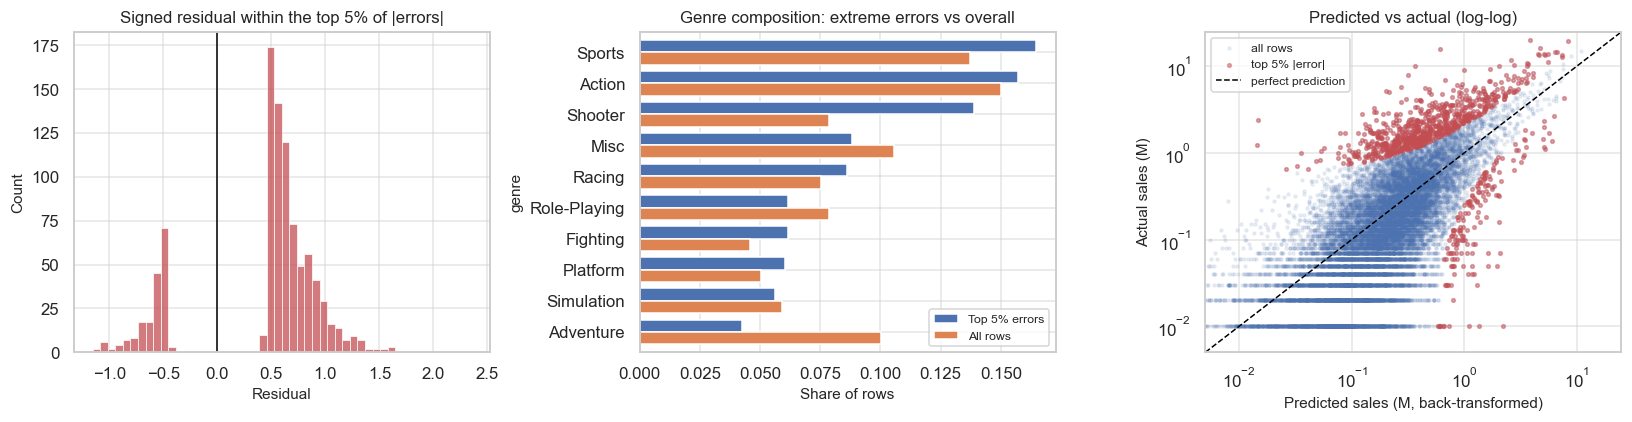

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(extreme_errors['residual'], bins=50, ax=axes[0], color='#C44E52')
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Signed residual within the top 5% of |errors|')
axes[0].set_xlabel('Residual')

genre_share = pd.DataFrame({
    'Top 5% errors': extreme_errors['genre'].value_counts(normalize=True),
    'All rows': error_frame['genre'].value_counts(normalize=True),
}).dropna().sort_values('Top 5% errors', ascending=False).head(10)
genre_share.plot.barh(ax=axes[1], width=0.8)
axes[1].invert_yaxis()
axes[1].set_title('Genre composition: extreme errors vs overall')
axes[1].set_xlabel('Share of rows')
axes[1].legend(fontsize=8)

axes[2].scatter(error_frame['predicted_sales'], error_frame['total_sales'],
                s=4, alpha=0.10, color='#4C72B0', label='all rows')
axes[2].scatter(extreme_errors['predicted_sales'], extreme_errors['total_sales'],
                s=6, alpha=0.45, color='#C44E52', label='top 5% |error|')
limit = [0.005, 25]
axes[2].plot(limit, limit, color='black', lw=1, ls='--', label='perfect prediction')
axes[2].set_xscale('log'); axes[2].set_yscale('log')
axes[2].set_xlim(0.005, 25); axes[2].set_ylim(0.005, 25)
axes[2].set_xlabel('Predicted sales (M, back-transformed)')
axes[2].set_ylabel('Actual sales (M)')
axes[2].set_title('Predicted vs actual (log-log)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [86]:
display_columns = ['title', 'console', 'genre', 'publisher', 'critic_score',
                   'release_year', 'platform_count', 'total_sales', 'predicted_sales',
                   'absolute_error']

print('=== The 12 largest absolute errors ===')
display(extreme_errors.nlargest(12, 'absolute_error')[display_columns].round(3)
        .reset_index(drop=True))

print('=== Largest UNDER-predictions: blockbusters the model did not see coming ===')
display(extreme_errors.nlargest(10, 'residual')[display_columns].round(3).reset_index(drop=True))

print('=== Largest OVER-predictions: titles the model expected to sell and they did not ===')
display(extreme_errors.nsmallest(10, 'residual')[display_columns].round(3).reset_index(drop=True))

=== The 12 largest absolute errors ===


,title,console,genre,publisher,critic_score,release_year,platform_count,total_sales,predicted_sales,absolute_error
0,Grand Theft Auto V,X360,Action,Rockstar Games,NaN,2013,8,15.86,0.612,2.348
1,Halo 4,X360,Shooter,Microsoft Studios,NaN,2012,1,9.96,0.367,2.081
2,The Sims 3,PC,Simulation,Electronic Arts,8.5,2009,10,7.96,0.317,1.917
3,Red Dead Redemption 2,XOne,Action-Adventure,Rockstar Games,NaN,2018,4,5.77,0.272,1.672
4,FIFA 19,PS4,Sports,Electronic Arts,NaN,2018,7,9.15,0.990,1.629
5,Microsoft Flight Simulator,PC,Simulation,Microsoft,7.0,1996,2,5.12,0.204,1.626
6,Warzone 2100,PS,Strategy,Eidos Interactive,NaN,1999,1,5.01,0.217,1.597
7,Just Dance 4,Wii,Music,Ubisoft,NaN,2012,4,6.89,0.682,1.546
8,Cooking Mama,DS,Simulation,Majesco,6.6,2006,2,5.66,0.453,1.523
9,Grand Theft Auto V,PS3,Action,Rockstar Games,9.4,2013,8,20.32,3.857,1.479


=== Largest UNDER-predictions: blockbusters the model did not see coming ===


,title,console,genre,publisher,critic_score,release_year,platform_count,total_sales,predicted_sales,absolute_error
0,Grand Theft Auto V,X360,Action,Rockstar Games,NaN,2013,8,15.86,0.612,2.348
1,Halo 4,X360,Shooter,Microsoft Studios,NaN,2012,1,9.96,0.367,2.081
2,The Sims 3,PC,Simulation,Electronic Arts,8.5,2009,10,7.96,0.317,1.917
3,Red Dead Redemption 2,XOne,Action-Adventure,Rockstar Games,NaN,2018,4,5.77,0.272,1.672
4,FIFA 19,PS4,Sports,Electronic Arts,NaN,2018,7,9.15,0.990,1.629
5,Microsoft Flight Simulator,PC,Simulation,Microsoft,7.0,1996,2,5.12,0.204,1.626
6,Warzone 2100,PS,Strategy,Eidos Interactive,NaN,1999,1,5.01,0.217,1.597
7,Just Dance 4,Wii,Music,Ubisoft,NaN,2012,4,6.89,0.682,1.546
8,Cooking Mama,DS,Simulation,Majesco,6.6,2006,2,5.66,0.453,1.523
9,Grand Theft Auto V,PS3,Action,Rockstar Games,9.4,2013,8,20.32,3.857,1.479


=== Largest OVER-predictions: titles the model expected to sell and they did not ===


,title,console,genre,publisher,critic_score,release_year,platform_count,total_sales,predicted_sales,absolute_error
0,Undertale,PS4,Role-Playing,Toby Fox,9.7,2017,4,0.01,2.205,1.155
1,Wolfenstein II: The New Colossus,PS4,Shooter,Bethesda Softworks,9.0,2017,4,1.36,6.095,1.101
2,Red Dead Redemption: Undead Nightmare,X360,Action,Rockstar Games,10.0,2010,5,1.11,5.241,1.085
3,Resident Evil 5: Gold Edition,X360,Action,Capcom,9.3,2010,3,0.00,1.904,1.066
4,WipEout HD Fury,PS3,Racing,Sony Computer Entertainment,9.1,2009,1,0.07,2.087,1.059
5,LittleBigPlanet: Game of the Year Edition,PS3,Platform,Sony Computer Entertainment,9.5,2009,1,0.00,1.879,1.058
6,Red Dead Redemption: Undead Nightmare,PS3,Action,Rockstar Games,10.0,2010,5,1.18,5.162,1.039
7,Hellblade: Senua's Sacrifice,PS4,Action-Adventure,505 Games,8.3,2018,5,0.05,1.959,1.036
8,Pillars of Eternity,PS4,Role-Playing,Paradox Interactive,8.3,2017,5,0.16,2.032,0.961
9,Resident Evil 5: Gold Edition,PS3,Action,Capcom,9.1,2010,3,0.00,1.609,0.959


#### Where do the extreme errors come from?

**The tail is one-sided.** Of 942 extreme errors, **760 (81%) are under-predictions**, with mean
actual sales of **2.21M against 0.35M** across the frame. The worst failures are concentrated in the
blockbuster tail, in one direction.

**1. Data quality.** The over-prediction list is dominated by rows that are not really lifetime sales.
`Resident Evil 5: Gold Edition` and `LittleBigPlanet: GOTY Edition` are re-releases recorded at
`total_sales = 0.00` while the model sees a strong franchise and predicts ~1.9M. `Undertale (PS4)`
records 0.01M because VGChartz tracks physical retail and Undertale sold digitally. One row is
literally titled `Pokémon Mystery Dungeon: Red Rescue Team (US weekly sales)`. These are not modelling
failures -- the target is **inconsistently defined** across rows.

**2. Model limitations.** `Grand Theft Auto V (X360)` sold 15.86M, predicted 0.61M; `Halo 4` sold
9.96M, predicted 0.37M. The features carry no franchise identity, marketing spend or sequel index, and
**55% of extreme errors have no `critic_score`**. The model knows "Rockstar Games, Action, 2013,
X360", and the median such game sells a few hundred thousand copies -- predicting the conditional
median is the rational response to an inadequate feature set.

**3. Rare / exceptional cases.** `Microsoft Flight Simulator (1996)` and `Warzone 2100 (PS, 1999)`
come from the thin, survivorship-biased pre-2000 region; `Just Dance 4` and `Cooking Mama` created
casual-gaming categories rather than fitting one. No pre-release feature would have flagged them.

**Consequence.** Category 1 should be *cleaned*, category 2 *engineered away*, and only category 3
accepted as a floor on achievable accuracy.

### B.5 Statistical properties of the errors (brief 1.4)

MAE, residual standard deviation, skewness and kurtosis are computed for every model, so the
distributional properties can be compared across modelling assumptions rather than read off a
single model.

In [87]:
error_statistics = []
for name, oof in regression_oof.items():
    model_residuals = y_regression - oof
    error_statistics.append({
        'Model': name,
        'MAE': mean_absolute_error(y_regression, oof),
        'Residual mean': model_residuals.mean(),
        'Residual median': np.median(model_residuals),
        'Residual std': model_residuals.std(),
        'Skewness': stats.skew(model_residuals),
        'Excess kurtosis': stats.kurtosis(model_residuals, fisher=True),
        'P95 |error|': np.quantile(np.abs(model_residuals), 0.95),
        'Max |error|': np.abs(model_residuals).max(),
    })

error_statistics = pd.DataFrame(error_statistics).set_index('Model')
display(error_statistics.round(4))

,MAE,Residual mean,Residual median,Residual std,Skewness,Excess kurtosis,P95 |error|,Max |error|
Model,,,,,,,,
Linear Regression,0.1725,0.0002,-0.0445,0.2604,2.2071,9.0236,0.5191,2.4993
Decision Tree,0.1595,0.0008,-0.0393,0.2538,1.9755,9.2585,0.5396,2.5551
Random Forest,0.1350,-0.0058,-0.0299,0.2165,1.8083,9.7844,0.4542,2.2766
Gradient Boosting,0.1344,0.0018,-0.0265,0.2124,1.7556,8.5764,0.4525,2.3476
KNN (bonus),0.1596,-0.0031,-0.0278,0.2491,1.5478,7.2255,0.5315,2.4492
SVR (bonus),0.1424,0.0408,-0.0152,0.2374,2.1210,9.2302,0.5285,2.5046


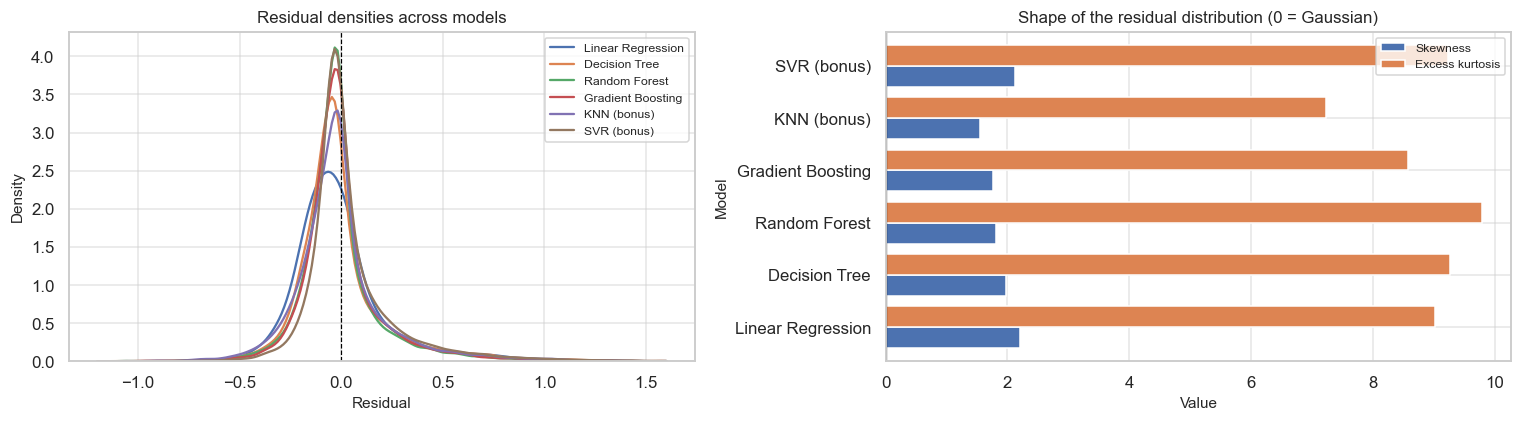

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, oof in regression_oof.items():
    sns.kdeplot(y_regression - oof, ax=axes[0], label=name, lw=1.5, clip=(-1.2, 1.6))
axes[0].axvline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Residual densities across models')
axes[0].set_xlabel('Residual')
axes[0].legend(fontsize=8)

skew_kurt = error_statistics[['Skewness', 'Excess kurtosis']]
skew_kurt.plot.barh(ax=axes[1], width=0.8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Shape of the residual distribution (0 = Gaussian)')
axes[1].set_xlabel('Value')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Interpretation

**Skewness -- systematic bias.** Every model has a **positively skewed** residual distribution
(Gradient Boosting ~1.76, Linear Regression ~2.21; Gaussian = 0), putting the long tail on the
*under-prediction* side and confirming B.2 and B.4. The ordering matters: the linear model is the most
skewed and the boosted model the least, so flexible models correct the bias partially, not fully.

**Kurtosis -- heavy tails and instability.** Excess kurtosis runs from **7.2 (KNN)** to **9.8 (Random
Forest)**, with Gradient Boosting at **8.6**, against 0 for a normal. So RMSE is hostage to a small
minority of rows -- P95 |error| (0.453) is **3.4x the MAE** (0.134) and the maximum (2.35) a further
**5x** beyond; any prediction interval built on a normal assumption is badly mis-calibrated; and
refitting on a slightly different sample moves the tail, which is the *instability* the brief refers
to and shows up in `RMSE_fold_std`.

**MAE vs RMSE.** MAE sits far below RMSE (0.134 vs 0.212) -- a ratio of ~0.63 where a Gaussian gives
~0.8. That gap measures tail-dominance, and it is why both are reported: MAE describes the typical
game, RMSE the exposure to the tail.

**SVR.** The only model with a materially non-zero mean residual (+0.041): its
$\varepsilon$-insensitive loss ignores errors under 0.05, which on an asymmetric target leaves a
persistent bias -- the *loss function*, not just the model class, shapes the error distribution.

### B.6 Are the linear-model assumptions satisfied?

Before the discussion, the OLS assumptions are tested explicitly rather than asserted.

In [89]:
linear_residuals = y_regression - regression_oof['Linear Regression']

assumption_checks = pd.DataFrame([
    {'Assumption': 'Zero-mean errors',
     'Test': 'one-sample t-test on residual mean',
     'Statistic': f'p = {stats.ttest_1samp(linear_residuals, 0).pvalue:.3f}',
     'Verdict': 'Satisfied on average'},
    {'Assumption': 'Homoskedasticity',
     'Test': 'Spearman corr(|residual|, fitted)',
     'Statistic': f'rho = {stats.spearmanr(np.abs(linear_residuals), regression_oof["Linear Regression"]).statistic:.3f}',
     'Verdict': 'Clearly violated'},
    {'Assumption': 'Normality of errors',
     'Test': "D'Agostino-Pearson normality test",
     'Statistic': f'p = {stats.normaltest(linear_residuals).pvalue:.2e}',
     'Verdict': 'Clearly violated (skew + heavy tails)'},
    {'Assumption': 'Linearity in the features',
     'Test': 'R2 gain of boosted trees over OLS',
     'Statistic': (f'{regression_summary.loc["Gradient Boosting", "R2"]:.3f} vs '
                   f'{regression_summary.loc["Linear Regression", "R2"]:.3f}'),
     'Verdict': 'Violated: large non-linear/interaction signal remains'},
    {'Assumption': 'Independent observations',
     'Test': 'structural check on the data',
     'Statistic': 'same title on multiple consoles / franchise entries',
     'Verdict': 'Violated: rows are clustered by title and franchise'},
]).set_index('Assumption')

display(assumption_checks)

,Test,Statistic,Verdict
Assumption,,,
Zero-mean errors,one-sample t-test on residual mean,p = 0.912,Satisfied on average
Homoskedasticity,"Spearman corr(|residual|, fitted)",rho = 0.519,Clearly violated
Normality of errors,D'Agostino-Pearson normality test,p = 0.00e+00,Clearly violated (skew + heavy tails)
Linearity in the features,R2 gain of boosted trees over OLS,0.546 vs 0.317,Violated: large non-linear/interaction signal ...
Independent observations,structural check on the data,same title on multiple consoles / franchise en...,Violated: rows are clustered by title and fran...


The independence violation deserves emphasis because it is invisible to any residual plot. Rows are
**not** independent draws: the same title appears on up to six consoles, and franchise entries share
a brand, an audience and a marketing machine. Random k-fold splitting therefore places `GTA V (PS3)`
in the training fold while `GTA V (X360)` is being predicted, which makes every score in this
notebook **mildly optimistic**. A grouped split (`GroupKFold` on `title`, or on a franchise key) would
give a more honest estimate of performance on a genuinely new title, and is the single most important
methodological improvement recommended in Part D.

### B.7 Regression discussion (brief section 2)

**Relative performance across metrics.** Gradient Boosting ($R^2 \approx 0.55$) ≳ Random Forest
($0.53$) > SVR ($0.42$) > KNN ($0.37$) > Decision Tree ($0.35$) > Linear Regression ($0.32$), stable
across MSE, RMSE, MAE and $R^2$. Two points matter more than the order: RF and GB tie on MAE (0.135 vs
0.134) and separate slightly on RMSE, so the boosted model's edge is in the tail rather than the
typical game; and no model exceeds $R^2 = 0.55$, leaving **~45% of the variance unexplained by any of
them** -- which points at the feature set, not the algorithms.

**Assumptions vs reality.** B.6 shows OLS operating outside its assumptions on three counts
(heteroscedasticity, non-normality, non-linearity) and *all* models violating independence. So OLS
standard errors are unreliable, its residuals are the most skewed of the six, and it cannot represent
the interaction structure the trees exploit.

**Bias-variance trade-off.** Linear Regression is the **high-bias** end -- it can only add main
effects -- and a depth-8 tree lowers bias only slightly (+0.03 $R^2$). Random Forest attacks
*variance* by averaging 300 decorrelated trees (**+0.18 $R^2$**, the largest jump in the table);
Gradient Boosting attacks *bias* by fitting residuals sequentially, gains +0.02, and pays with the
largest fold spread of the tree models (0.0062 vs 0.0047). Textbook intuition fails in one place worth
naming: the linear model should show the *lowest* fold variance and does not (0.0058), because ~100
partly collinear one-hot columns and a heavy-tailed target make the OLS solution itself move between
folds, while bagging averages that instability away. KNN is high-variance *without* compensating
structure -- in ~100 mostly-binary dimensions, the 15 nearest neighbours of a game are not similar to it.

**Sensitivity to outliers and noise.** Linear Regression is most exposed: squared loss on a
heavy-tailed target lets a few blockbusters pull the whole hyperplane. Tree ensembles are structurally
robust because splits depend on the *ordering* of feature values, not their magnitude, so an extreme
target distorts only its own leaf. SVR is robust by construction, which is why it beats KNN despite
unfavourable geometry -- but that same $\varepsilon$-insensitive loss leaves it biased.

**Where linear models fail.** (a) The response is *interaction-driven* -- `console` depends jointly on
`genre`, `release_year` and `publisher`. (b) `critic_score`'s error behaviour is **non-monotone**, flat
below 7 and explosive above, which one slope cannot express. (c) Error variance grows sevenfold across
the prediction range, violating the assumption OLS most relies on for inference.

**Where tree models win.** Where structure is *conditional and local*. Frequency-encoded
`publisher`/`developer` only become useful once a tree can split on them and ask a different question
per branch, and trees can isolate "no critic score" as its own region instead of treating an imputed
7.4 as a measurement.

**Interpretability vs performance.** OLS gives readable coefficients and costs 0.23 $R^2$; a depth-8
tree stays readable and recovers only 0.03. The full 0.23 needs 300 trees or 400 boosting iterations
-- not inspectable as rules, though explainable post hoc via permutation importance or SHAP.
Transparency here costs ~40% of the achievable explained variance.

**Preferred model: Gradient Boosting.** Best RMSE, MSE and $R^2$; the least skewed and least
heavy-tailed residuals, so its errors are the best behaved; native handling of missing and mixed-type
features. Random Forest is the reasonable alternative -- B.1 showed the accuracy gap sits inside fold
noise -- and would win if fold-to-fold consistency mattered more than the tail.

**What the modelling stage taught.** The *target definition* was the highest-leverage decision here:
excluding regional sales took $R^2$ from a meaningless ~1.0 to an honest 0.55. A better metric is not
a better *error structure* -- RF and GB tie on accuracy and differ in the tail, which only error
analysis reveals. And the ceiling is set by **missing features, not model capacity**: every model
fails on the same rows in the same direction.

---

## Part C -- Classification Error Analysis (brief section 3)

### C.1 Problem definition

A title is labelled a **hit** if it sold at least **1.0M units**. The threshold is not arbitrary:
"million-seller" is the industry's own standard for commercial success, and it produces a
**7.99% positive rate** -- imbalanced enough to make accuracy useless and the threshold analysis of
section C.5 genuinely necessary, but with ~1,500 positives, still enough to estimate precision and
recall reliably.

The feature set, preprocessing and fold seed are **identical to Part B**; only the target and the
estimator family change. `StratifiedKFold` preserves the 8% positive rate in every fold.

In [90]:
CLASSIFICATION_MODELS = {
    'Logistic Regression': ModelSpec(
        LogisticRegression(max_iter=3000), True, 'Linear (baseline)',
        'default L2, max_iter=3000; features standardised'),
    'Decision Tree': ModelSpec(
        DecisionTreeClassifier(max_depth=8, min_samples_leaf=25, random_state=RANDOM_STATE),
        False, 'Single tree', 'max_depth=8, min_samples_leaf=25'),
    'Random Forest': ModelSpec(
        RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                               n_jobs=-1, random_state=RANDOM_STATE),
        False, 'Bagging ensemble', 'n_estimators=300, min_samples_leaf=2'),
    'Gradient Boosting': ModelSpec(
        HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                       random_state=RANDOM_STATE),
        False, 'Boosting ensemble', 'max_iter=400, learning_rate=0.06'),
}

display(pd.DataFrame(
    [{'Model': name, 'Family': spec.family, 'Hyperparameters': spec.hyperparameters}
     for name, spec in CLASSIFICATION_MODELS.items()]).set_index('Model'))

classification_oof = {}
classification_rows = []

for name, spec in CLASSIFICATION_MODELS.items():
    pipeline = build_pipeline(spec.estimator, spec.scale_numeric)
    probabilities, folds = cross_validate_oof(pipeline, X, y_classification,
                                              CLASSIFICATION_CV, task='classification')
    labels = (probabilities >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_classification, labels).ravel()

    classification_oof[name] = probabilities
    classification_rows.append({
        'Model': name,
        'ROC_AUC': roc_auc_score(y_classification, probabilities),
        'PR_AUC': average_precision_score(y_classification, probabilities),
        'Precision': precision_score(y_classification, labels, zero_division=0),
        'Recall': recall_score(y_classification, labels),
        'F1': f1_score(y_classification, labels),
        'MCC': matthews_corrcoef(y_classification, labels),
        'Balanced acc.': balanced_accuracy_score(y_classification, labels),
        'Brier': brier_score_loss(y_classification, probabilities),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    })
    print(f'{name:<20s} done')

classification_summary = pd.DataFrame(classification_rows).set_index('Model')
print(f'\nPositive class: {y_classification.sum():,} of {len(y_classification):,} '
      f'({y_classification.mean():.2%}) -- a model predicting "never a hit" would score '
      f'{1 - y_classification.mean():.2%} accuracy.')
display(classification_summary.round(4))

,Family,Hyperparameters
Model,,
Logistic Regression,Linear (baseline),"default L2, max_iter=3000; features standardised"
Decision Tree,Single tree,"max_depth=8, min_samples_leaf=25"
Random Forest,Bagging ensemble,"n_estimators=300, min_samples_leaf=2"
Gradient Boosting,Boosting ensemble,"max_iter=400, learning_rate=0.06"


Logistic Regression  done
Decision Tree        done
Random Forest        done
Gradient Boosting    done

Positive class: 1,504 of 18,829 (7.99%) -- a model predicting "never a hit" would score 92.01% accuracy.


,ROC_AUC,PR_AUC,Precision,Recall,F1,MCC,Balanced acc.,Brier,TN,FP,FN,TP
Model,,,,,,,,,,,,
Logistic Regression,0.8405,0.4204,0.6586,0.1988,0.3054,0.3355,0.5949,0.0582,17170,155,1205,299
Decision Tree,0.8139,0.3782,0.5916,0.2061,0.3057,0.3194,0.5969,0.0611,17111,214,1194,310
Random Forest,0.8984,0.5574,0.8159,0.2121,0.3367,0.3953,0.6040,0.0512,17253,72,1185,319
Gradient Boosting,0.8974,0.5663,0.7183,0.3238,0.4464,0.4551,0.6564,0.0495,17134,191,1017,487


**Reading the table.** Gradient Boosting and Random Forest both reach **ROC-AUC ≈ 0.90**, which sounds
excellent -- but their **PR-AUC is only ~0.56**, and at the default 0.5 threshold recall is
**0.21-0.32**. This gap is the most important single fact in Part C: ROC-AUC is computed against the
majority class and is flattered by 17,325 easy negatives, whereas PR-AUC and MCC reflect performance
on the 8% that matter. **Accuracy is not reported at all**: predicting "never a hit" would score
92.0% and be completely useless. Gradient Boosting is selected as the primary classifier -- highest
PR-AUC, F1, MCC and the lowest Brier score.

### C.2 Confusion matrix analysis (brief 3.1)

In [91]:
BEST_CLASSIFIER = classification_summary['PR_AUC'].idxmax()
print(f'Primary classifier (highest PR-AUC): {BEST_CLASSIFIER}')

hit_probability = classification_oof[BEST_CLASSIFIER]
predicted_hit = (hit_probability >= 0.5).astype(int)
is_correct = predicted_hit == y_classification

classification_frame = games.assign(
    hit_probability=hit_probability,
    predicted_hit=predicted_hit,
    is_correct=is_correct,
    outcome=np.select(
        [(y_classification == 1) & (predicted_hit == 1),
         (y_classification == 0) & (predicted_hit == 0),
         (y_classification == 0) & (predicted_hit == 1)],
        ['True Positive', 'True Negative', 'False Positive'],
        default='False Negative'),
)

Primary classifier (highest PR-AUC): Gradient Boosting


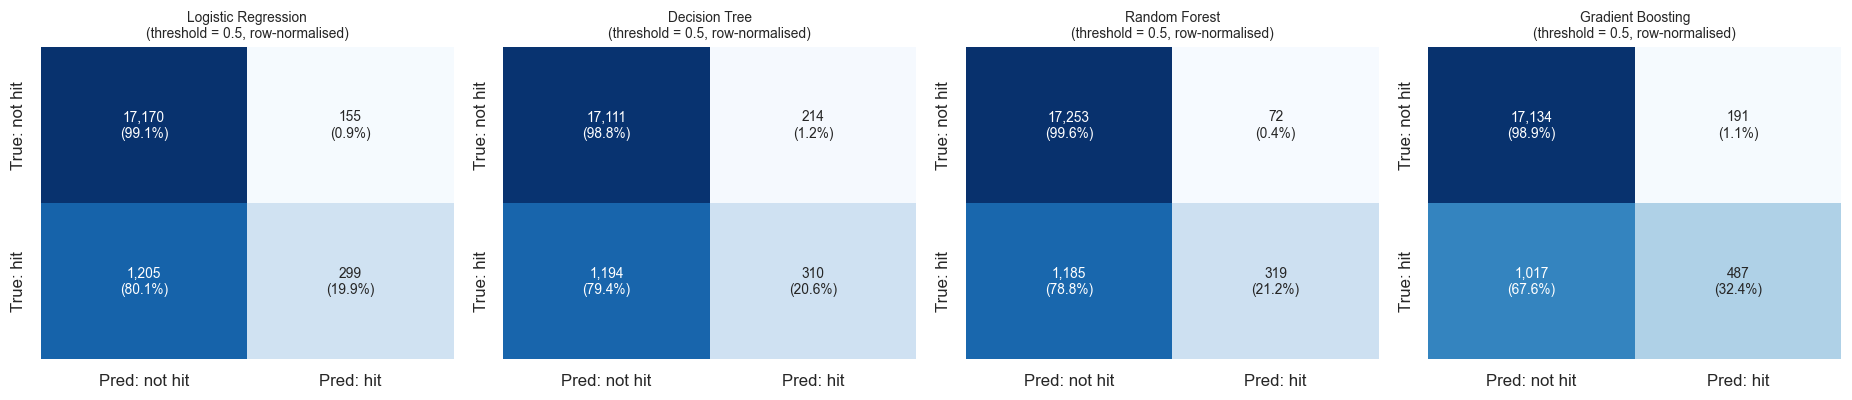

Gradient Boosting at threshold 0.5
  True Negatives : 17,134   False Positives:    191
  False Negatives:  1,017   True Positives :    487
  Precision 0.718 | Recall 0.324 | FN:FP ratio 5.3 : 1
  Missed sales volume: 1,805M units of the 3,364M units in the hit class


In [92]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (name, probabilities) in zip(axes, classification_oof.items()):
    matrix = confusion_matrix(y_classification, (probabilities >= 0.5).astype(int))
    normalised = matrix / matrix.sum(axis=1, keepdims=True)
    annotations = np.array([[f'{matrix[i, j]:,}\n({normalised[i, j]:.1%})' for j in range(2)]
                            for i in range(2)])
    sns.heatmap(normalised, annot=annotations, fmt='', cmap='Blues', cbar=False, ax=ax,
                vmin=0, vmax=1, xticklabels=['Pred: not hit', 'Pred: hit'],
                yticklabels=['True: not hit', 'True: hit'], annot_kws={'size': 9})
    ax.set_title(f'{name}\n(threshold = 0.5, row-normalised)', fontsize=9)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_classification, predicted_hit).ravel()
print(f'{BEST_CLASSIFIER} at threshold 0.5')
print(f'  True Negatives : {tn:6,}   False Positives: {fp:6,}')
print(f'  False Negatives: {fn:6,}   True Positives : {tp:6,}')
print(f'  Precision {tp / (tp + fp):.3f} | Recall {tp / (tp + fn):.3f} | '
      f'FN:FP ratio {fn / max(fp, 1):.1f} : 1')
print(f'  Missed sales volume: {games.loc[(y_classification == 1) & (predicted_hit == 0), "total_sales"].sum():,.0f}M units '
      f'of the {games.loc[y_classification == 1, "total_sales"].sum():,.0f}M units in the hit class')

#### Interpretation

**One cell dominates.** At threshold 0.5 the model gives **1,017 false negatives against 191 false
positives** -- 5.3 : 1. Precision is high (0.72), recall low (0.32): when it says "hit" it is usually
right, but it stays silent for two thirds of actual hits. That is expected for a classifier trained at
an 8% positive rate and thresholded at 0.5, since "P(hit) > 0.5" demands a title be *more likely than
not* to be a million-seller. The model is not broken -- **the threshold is mis-specified for the class
balance**, which C.5 corrects.

**Which error is more critical?** It depends on the decision, and the two realistic use-cases point
opposite ways. For **investment / greenlighting**, a false positive costs real money and precision
matters, so 0.5 is defensible. For **discovery / screening**, a false negative is the costly error --
in a hit-driven market one missed million-seller outweighs many wasted evaluations. The second fits
this dataset better, and the numbers back it: those 1,017 false negatives account for **1,805M of the
3,364M units (54%)** sold by the hit class. Because the framings genuinely conflict, the responsible
output is not one confusion matrix but the **threshold curve** of C.5.

**Systematic failure regions.** The four matrices differ less than the headline metrics suggest. At
threshold 0.5, recall is 0.199 (Logistic Regression), 0.206 (Decision Tree) and **0.212 (Random
Forest)** -- the forest barely improves on the linear baseline, despite a far better PR-AUC (0.557 vs
0.420). Only Gradient Boosting genuinely moves, to **0.324**.

The reason is the ensemble-probability effect C.5 returns to. A bagged forest's P(hit) is a vote share
across 300 trees, so it is well *ranked* but compressed towards zero; at a fixed 0.5 cut-off that
compression cancels most of the ranking advantage, leaving very high precision (0.816) on very few
positive predictions. Boosting outputs uncompressed log-odds and does not suffer this. It is a concrete
demonstration that **a better-ordered model is not automatically a better classifier at a fixed
threshold** -- ranking quality and decision quality are separate properties, and only the threshold
sweep of C.5 reconciles them. All four models nonetheless fail in the *same direction* on the *same
kind of row*, so the failure is a property of the problem; C.4 localises which rows.

### C.3 Probability-based analysis (brief 3.2)

The objective is to identify **high-confidence errors** -- cases where the model was not merely wrong
but confidently wrong, which are the dangerous ones in deployment.

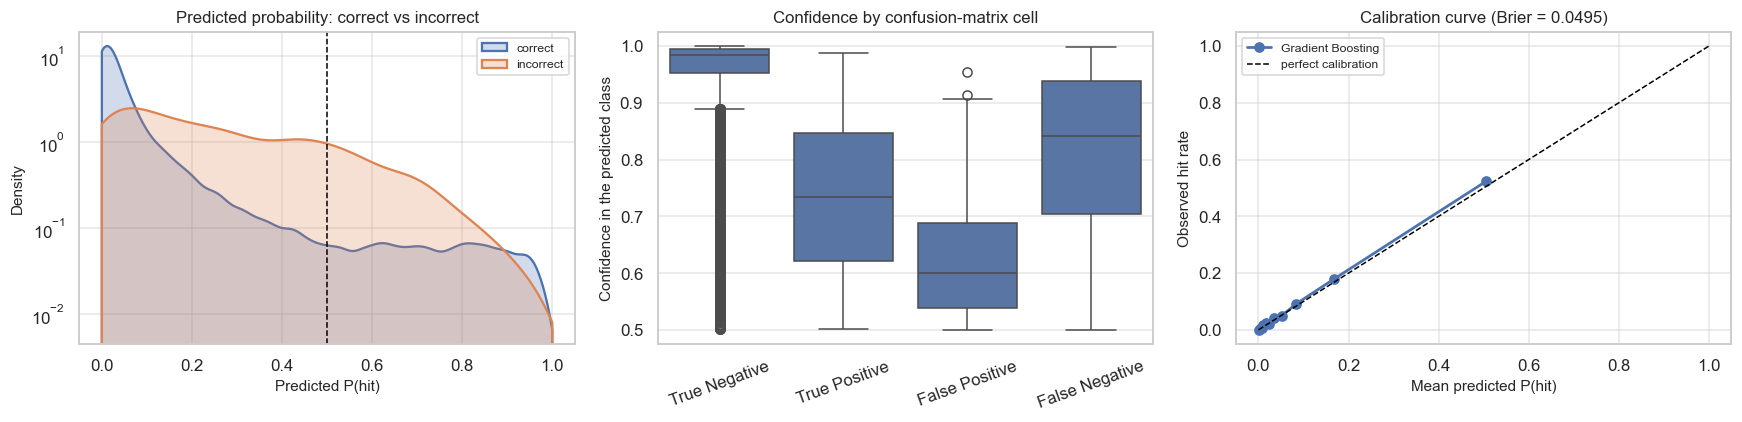

In [93]:
confidence_in_prediction = np.maximum(hit_probability, 1 - hit_probability)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.kdeplot(x=hit_probability[is_correct], ax=axes[0], label='correct', fill=True,
            clip=(0, 1), lw=1.5)
sns.kdeplot(x=hit_probability[~is_correct], ax=axes[0], label='incorrect', fill=True,
            clip=(0, 1), lw=1.5)
axes[0].axvline(0.5, color='black', ls='--', lw=1)
axes[0].set_yscale('log')
axes[0].set_xlabel('Predicted P(hit)')
axes[0].set_title('Predicted probability: correct vs incorrect')
axes[0].legend(fontsize=8)

sns.boxplot(x=classification_frame['outcome'], y=confidence_in_prediction, ax=axes[1],
            order=['True Negative', 'True Positive', 'False Positive', 'False Negative'])
axes[1].set_ylabel('Confidence in the predicted class')
axes[1].set_xlabel('')
axes[1].set_title('Confidence by confusion-matrix cell')
axes[1].tick_params(axis='x', rotation=20)

fraction_positive, mean_predicted = calibration_curve(y_classification, hit_probability,
                                                      n_bins=12, strategy='quantile')
axes[2].plot(mean_predicted, fraction_positive, marker='o', lw=1.8, label=BEST_CLASSIFIER)
axes[2].plot([0, 1], [0, 1], ls='--', color='black', lw=1, label='perfect calibration')
axes[2].set_xlabel('Mean predicted P(hit)')
axes[2].set_ylabel('Observed hit rate')
axes[2].set_title(f'Calibration curve (Brier = '
                  f'{brier_score_loss(y_classification, hit_probability):.4f})')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [94]:
HIGH_CONFIDENCE = 0.80
high_confidence_fp = (hit_probability >= HIGH_CONFIDENCE) & (y_classification == 0)
high_confidence_fn = (hit_probability <= 1 - HIGH_CONFIDENCE) & (y_classification == 1)

print(f'Mean P(hit)                     : correct {hit_probability[is_correct].mean():.4f} | '
      f'incorrect {hit_probability[~is_correct].mean():.4f}')
print(f'Mean confidence in predicted class: correct {confidence_in_prediction[is_correct].mean():.4f} | '
      f'incorrect {confidence_in_prediction[~is_correct].mean():.4f}')
print()
print(f'High-confidence false positives (P >= {HIGH_CONFIDENCE:.2f}, not a hit): '
      f'{high_confidence_fp.sum():,}  ({high_confidence_fp.sum() / max(fp, 1):.1%} of all FP)')
print(f'High-confidence false negatives (P <= {1 - HIGH_CONFIDENCE:.2f}, actually a hit): '
      f'{high_confidence_fn.sum():,}  ({high_confidence_fn.sum() / max(fn, 1):.1%} of all FN)')

probe_columns = ['title', 'console', 'genre', 'publisher', 'critic_score',
                 'release_year', 'platform_count', 'total_sales', 'hit_probability']

print('\n=== Most confident FALSE POSITIVES: predicted hits that were not ===')
display(classification_frame[high_confidence_fp].nlargest(8, 'hit_probability')[probe_columns]
        .round(3).reset_index(drop=True))

print('=== Most confident FALSE NEGATIVES: hits the model was sure would flop ===')
display(classification_frame[high_confidence_fn].nsmallest(8, 'hit_probability')[probe_columns]
        .round(3).reset_index(drop=True))

Mean P(hit)                     : correct 0.0631 | incorrect 0.2587
Mean confidence in predicted class: correct 0.9498 | incorrect 0.7802

High-confidence false positives (P >= 0.80, not a hit): 13  (6.8% of all FP)
High-confidence false negatives (P <= 0.20, actually a hit): 589  (57.9% of all FN)

=== Most confident FALSE POSITIVES: predicted hits that were not ===


,title,console,genre,publisher,critic_score,release_year,platform_count,total_sales,hit_probability
0,LEGO Harry Potter: Years 5-7,PS3,Action,Warner Bros. Interactive,9.0,2011,9,0.95,0.953
1,Ridge Racer,PS,Racing,Namco,9.0,1995,5,0.79,0.913
2,Star Soldier,NES,Shooter,Taxan,NaN,1988,3,0.96,0.906
3,Rock Band 3,X360,Misc,MTV Games,9.4,2010,5,0.88,0.890
4,Burnout Revenge,PS2,Racing,Electronic Arts,9.0,2005,4,0.90,0.858
5,007: Quantum of Solace,PS2,Shooter,Activision,7.8,2008,6,0.43,0.842
6,Bust-A-Move 4,PS,Puzzle,Natsume,7.8,1998,4,0.22,0.842
7,Madden NFL 16,PS3,Sports,EA Sports,8.0,2015,4,0.81,0.842


=== Most confident FALSE NEGATIVES: hits the model was sure would flop ===


,title,console,genre,publisher,critic_score,release_year,platform_count,total_sales,hit_probability
0,No Man's Sky,PS4,Action-Adventure,Hello Games,6.8,2016,6,2.26,0.002
1,Dragon Quest XI,3DS,Role-Playing,Square Enix,NaN,2017,2,1.82,0.002
2,Tomodachi Collection: New Life,3DS,Simulation,Nintendo,NaN,2013,1,1.69,0.003
3,Naruto: Clash of Ninja Revolution,Wii,Fighting,Tomy Corporation,NaN,2007,1,1.02,0.004
4,RollerCoaster Tycoon 2,PC,Strategy,Atari,7.3,2002,1,1.25,0.004
5,Minecraft: Story Mode,X360,Adventure,Mojang,NaN,2015,7,1.20,0.004
6,The Elder Scrolls Online,PC,MMO,Bethesda Softworks,NaN,2014,3,1.02,0.005
7,Pokémon Conquest,DS,Role-Playing,Nintendo,NaN,2012,1,1.02,0.005


#### Interpretation

**Confidence separates right from wrong -- weakly and asymmetrically.** Mean confidence in the
predicted class is **0.95 when correct and 0.78 when incorrect**, so the model's uncertainty is a
usable routing signal, and the calibration curve tracks the diagonal (Brier ≈ 0.050) so the
probabilities can be read as approximate probabilities.

**But the two error types differ completely.** Only **13 false positives (6.8%)** are high-confidence,
against **589 false negatives (58%)** -- the model assigns P(hit) ≤ 0.20 to more than half the hits it
misses. **It is not uncertain about the hits it misses; it is confidently wrong about them.**

**Why.** `No Man's Sky` (2.26M actual, P = 0.002) was driven by a marketing phenomenon no feature
captures. `Dragon Quest XI (3DS)`, `Tomodachi Collection (3DS)` and `Pokémon Conquest (DS)` are
**Japan-dominated titles** -- HW1's second core insight was exactly that Japan is a decoupled market
($r \approx 0.07\text{–}0.21$ with Western regions). The model learned a Western notion of a hit, so a
Japanese handheld million-seller is not borderline to it; it is confidently outside the pattern.
`The Elder Scrolls Online` (MMO) and `Minecraft: Story Mode` (episodic) are business models the
training data barely contains.

**The warning.** A confidence threshold is a safety net for *known* unknowns. It works for false
positives but would miss most false negatives, which come from regions where the model is wrong *and*
certain. Coverage failures are fixed with features and data, not thresholds.

### C.4 Error as a function of the features (brief 3.3)

Feature distributions are compared between correctly and incorrectly classified rows, to locate the
regions of feature space that are prone to misclassification.

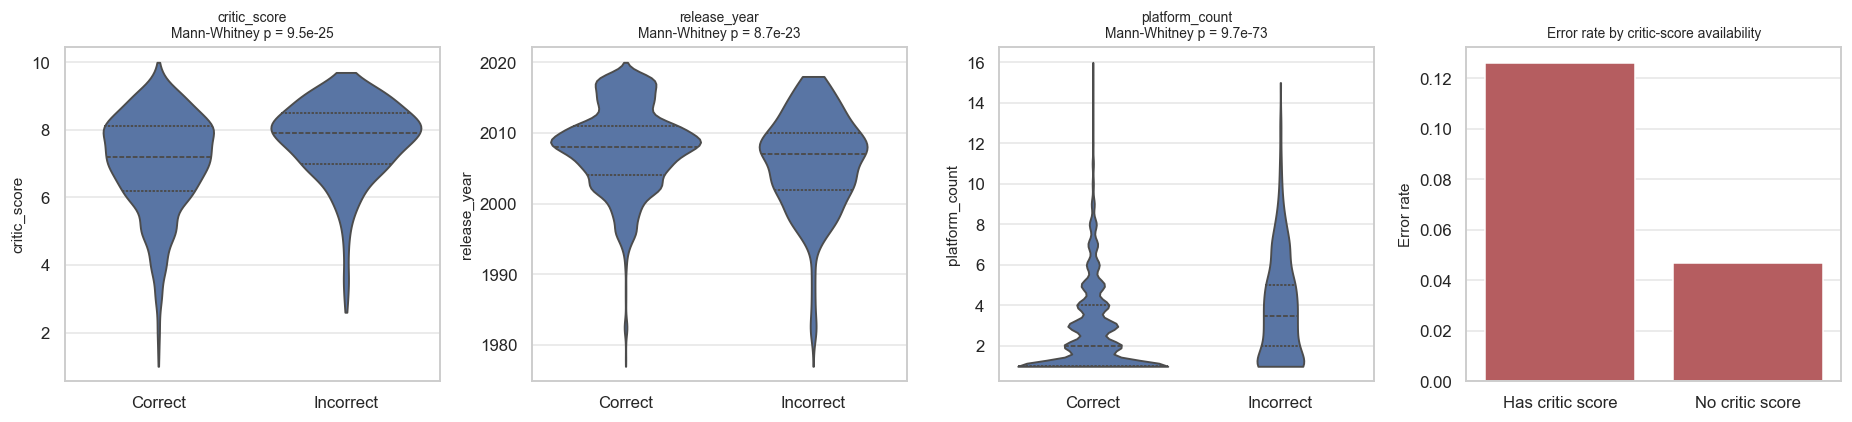

,median_correct,median_incorrect,mean_correct,mean_incorrect,mann_whitney_p
feature,,,,,
critic_score,7.2,7.9,7.0188,7.6769,9.50e-25
release_year,2008.0,2007.0,2007.8179,2005.7831,8.67e-23
platform_count,2.0,3.5,2.6529,3.8940,9.68e-73


,n,error_rate,hit_rate
has_score,,,
Has critic score,4123,0.1261,0.1848
No critic score,14706,0.0468,0.0505


In [95]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
correctness_label = np.where(is_correct, 'Correct', 'Incorrect')

for ax, feature in zip(axes[:3], ['critic_score', 'release_year', 'platform_count']):
    sns.violinplot(x=correctness_label, y=classification_frame[feature], ax=ax,
                   order=['Correct', 'Incorrect'], cut=0, inner='quartile')
    subset_correct = classification_frame.loc[is_correct, feature].dropna()
    subset_incorrect = classification_frame.loc[~is_correct, feature].dropna()
    p_value = stats.mannwhitneyu(subset_correct, subset_incorrect).pvalue
    ax.set_title(f'{feature}\nMann-Whitney p = {p_value:.1e}', fontsize=9)
    ax.set_xlabel('')

critic_availability = (classification_frame
                       .assign(has_score=np.where(classification_frame['has_critic_score'] == 1,
                                                  'Has critic score', 'No critic score'))
                       .groupby('has_score')['is_correct']
                       .apply(lambda s: 1 - s.mean()))
sns.barplot(x=critic_availability.index, y=critic_availability.values, ax=axes[3], color='#C44E52')
axes[3].set_ylabel('Error rate')
axes[3].set_xlabel('')
axes[3].set_title('Error rate by critic-score availability', fontsize=9)

plt.tight_layout()
plt.show()

# Numeric backing for the figure above (medians, effect direction, significance).
correctness_comparison = pd.DataFrame([
    {'feature': feature,
     'median_correct': classification_frame.loc[is_correct, feature].median(),
     'median_incorrect': classification_frame.loc[~is_correct, feature].median(),
     'mean_correct': classification_frame.loc[is_correct, feature].mean(),
     'mean_incorrect': classification_frame.loc[~is_correct, feature].mean(),
     'mann_whitney_p': stats.mannwhitneyu(
         classification_frame.loc[is_correct, feature].dropna(),
         classification_frame.loc[~is_correct, feature].dropna()).pvalue}
    for feature in ['critic_score', 'release_year', 'platform_count']
]).set_index('feature')
display(correctness_comparison.round(4)
        .assign(mann_whitney_p=correctness_comparison['mann_whitney_p'].map('{:.2e}'.format)))

critic_availability_detail = (classification_frame
    .assign(has_score=np.where(classification_frame['has_critic_score'] == 1,
                               'Has critic score', 'No critic score'),
            is_error=~classification_frame['is_correct'])
    .groupby('has_score')
    .agg(n=('is_error', 'size'), error_rate=('is_error', 'mean'), hit_rate=('is_hit', 'mean')))
display(critic_availability_detail.round(4))

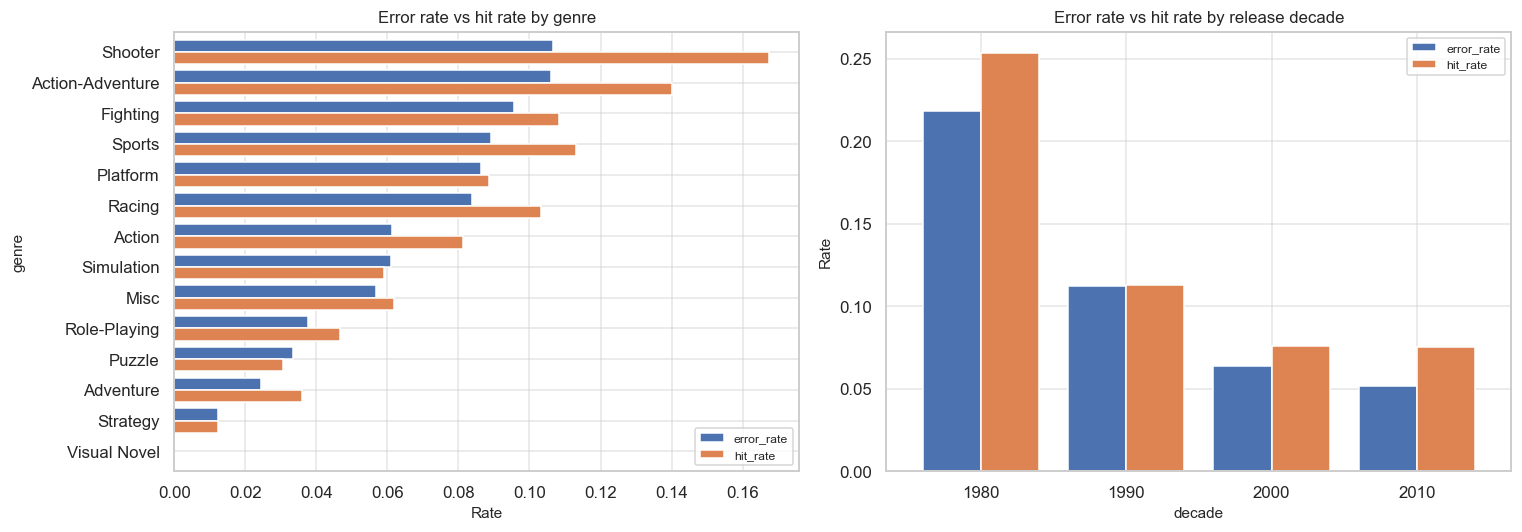

,n,error_rate,hit_rate,mean_sales
genre,,,,
Shooter,1480,0.1068,0.1676,0.6726
Action-Adventure,264,0.1061,0.1402,0.5626
Fighting,867,0.0957,0.1084,0.3926
Sports,2580,0.0891,0.1132,0.4600
Platform,949,0.0864,0.0885,0.3679
Racing,1422,0.0837,0.1034,0.3682
Action,2825,0.0612,0.0814,0.3982
Simulation,1116,0.0609,0.0591,0.2692
Misc,1987,0.0569,0.0619,0.2803


,n,error_rate,hit_rate,mean_sales
console,,,,
PS,1129,0.1355,0.1364,0.4838
PS2,2119,0.1015,0.1255,0.4839
PS3,1340,0.0985,0.1567,0.6261
X360,1294,0.0974,0.1669,0.6641
XOne,524,0.0897,0.1393,0.5133
PS4,908,0.0782,0.1322,0.5946
Wii,1345,0.0751,0.0781,0.3412
XB,836,0.0586,0.0562,0.2776
SNES,197,0.0508,0.0508,0.3336


,n,error_rate,hit_rate
decade,,,
1980,142,0.2183,0.2535
1990,1514,0.1123,0.1129
2000,10027,0.0635,0.0759
2010,7107,0.0519,0.0753


In [96]:
def misclassification_profile(column, min_count=150):
    return (classification_frame
            .assign(is_error=~classification_frame['is_correct'])
            .groupby(column)
            .agg(n=('is_error', 'size'),
                 error_rate=('is_error', 'mean'),
                 hit_rate=('is_hit', 'mean'),
                 mean_sales=('total_sales', 'mean'))
            .query('n >= @min_count')
            .sort_values('error_rate', ascending=False))


genre_misclassification = misclassification_profile('genre')
console_misclassification = misclassification_profile('console')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
genre_misclassification[['error_rate', 'hit_rate']].plot.barh(ax=axes[0], width=0.8)
axes[0].invert_yaxis()
axes[0].set_title('Error rate vs hit rate by genre')
axes[0].set_xlabel('Rate')
axes[0].legend(fontsize=8)

decade_profile = (classification_frame
                  .assign(is_error=~classification_frame['is_correct'],
                          decade=(classification_frame['release_year'] // 10 * 10))
                  .groupby('decade')
                  .agg(n=('is_error', 'size'), error_rate=('is_error', 'mean'),
                       hit_rate=('is_hit', 'mean'))
                  .query('n >= 100'))
decade_profile[['error_rate', 'hit_rate']].plot.bar(ax=axes[1], width=0.8)
axes[1].set_title('Error rate vs hit rate by release decade')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

display(genre_misclassification.round(4))
display(console_misclassification.head(10).round(4))
display(decade_profile.round(4))

#### Interpretation

**Every comparison is significant, and all point the same way.** Misclassified titles have a higher
median critic score (7.9 vs 7.2, p ≈ 1e-24), an earlier median release year (2007 vs 2008, p ≈ 9e-23)
and a much higher platform count (3.5 vs 2.0, p ≈ 1e-72). **Multi-platform release is the single best
predictor of the model being wrong.**

**Error rate tracks the hit rate almost exactly.** In both panels the bars move together: Shooter
(16.8% hit rate → 10.7% error rate), Action-Adventure (14.0% → 10.6%), Fighting, Sports and Racing at
the top; Strategy (1.2% → 1.2%), Adventure, Puzzle and Visual Novel (0% → 0%) at the bottom. This is
the classification-side echo of Part B's heteroscedasticity: **the model is only wrong near the
decision boundary, and only genres with a real hit rate have rows there.** The apparent competence on
Visual Novel and Strategy is the base rate, not skill.

**Critic-score availability splits the data again.** 12.6% error rate with a score against **4.7%**
without, on hit rates of 18.5% and 5.1% -- same mechanism as B.3.

**The 1980s are the exception:** a **21.8% error rate** against a 25.4% hit rate on 142 rows. VGChartz
recorded 1980s titles mainly *because* they were notable, so a quarter are million-sellers and the
model has almost no data for the era.

**Regions prone to misclassification:** multi-platform, critically reviewed, Western-console titles in
high-hit-rate genres, plus the thin pre-2000 tail and the Japan-dominated titles from C.3 -- the same
rows that dominated the regression's extreme errors.

### C.5 Threshold sensitivity analysis (brief 3.4)

Performance is evaluated across thresholds 0.1, 0.2, ..., 0.9, together with the $F_\beta$ curve,
MCC, and the ROC curve with its AUC.

In [97]:
def sweep_thresholds(y_true, probabilities, thresholds=np.arange(0.1, 0.95, 0.1)):
    rows = []
    for threshold in thresholds:
        labels = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, labels, labels=[0, 1]).ravel()
        rows.append({
            'Threshold': round(float(threshold), 1),
            'Precision': precision_score(y_true, labels, zero_division=0),
            'Recall': recall_score(y_true, labels, zero_division=0),
            'F1': f1_score(y_true, labels, zero_division=0),
            'F0.5': fbeta_score(y_true, labels, beta=0.5, zero_division=0),
            'F2': fbeta_score(y_true, labels, beta=2, zero_division=0),
            'MCC': matthews_corrcoef(y_true, labels),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        })
    return pd.DataFrame(rows).set_index('Threshold')


threshold_table = sweep_thresholds(y_classification, hit_probability)
display(threshold_table.round(4))

print(f'Best F1  at threshold {threshold_table["F1"].idxmax():.1f}  (F1  = {threshold_table["F1"].max():.4f})')
print(f'Best MCC at threshold {threshold_table["MCC"].idxmax():.1f}  (MCC = {threshold_table["MCC"].max():.4f})')
print(f'Best F2  at threshold {threshold_table["F2"].idxmax():.1f}  (F2  = {threshold_table["F2"].max():.4f})')
print(f'Best F0.5 at threshold {threshold_table["F0.5"].idxmax():.1f} (F0.5 = {threshold_table["F0.5"].max():.4f})')

,Precision,Recall,F1,F0.5,F2,MCC,TP,FP,FN,TN
Threshold,,,,,,,,,,
0.1,0.3356,0.7606,0.4657,0.3778,0.6069,0.4435,1144,2265,360,15060
0.2,0.4726,0.6084,0.5320,0.4947,0.5753,0.4904,915,1021,589,16304
0.3,0.5625,0.4880,0.5226,0.5458,0.5013,0.4858,734,571,770,16754
0.4,0.6485,0.4109,0.5031,0.5813,0.4434,0.4843,618,335,886,16990
0.5,0.7183,0.3238,0.4464,0.5776,0.3638,0.4551,487,191,1017,17134
0.6,0.8033,0.2580,0.3905,0.5646,0.2985,0.4330,388,95,1116,17230
0.7,0.8842,0.1828,0.3030,0.5004,0.2173,0.3845,275,36,1229,17289
0.8,0.9319,0.1184,0.2100,0.3924,0.1434,0.3182,178,13,1326,17312
0.9,0.9565,0.0439,0.0839,0.1854,0.0542,0.1961,66,3,1438,17322


Best F1  at threshold 0.2  (F1  = 0.5320)
Best MCC at threshold 0.2  (MCC = 0.4904)
Best F2  at threshold 0.1  (F2  = 0.6069)
Best F0.5 at threshold 0.4 (F0.5 = 0.5813)


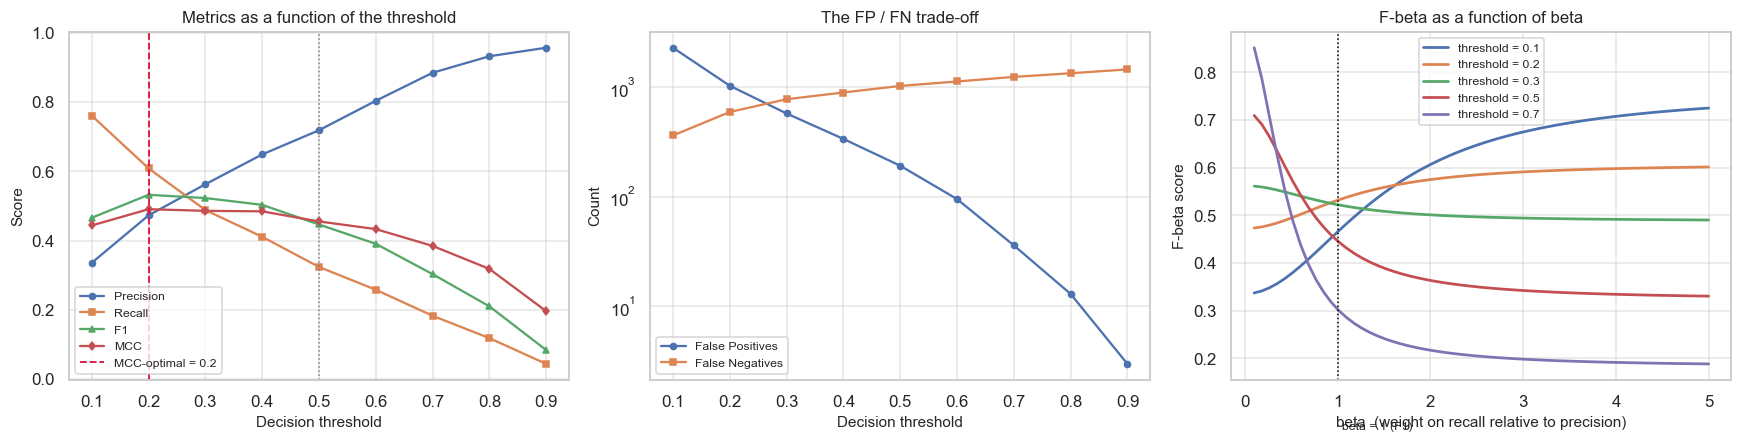

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

for metric, style in [('Precision', '-o'), ('Recall', '-s'), ('F1', '-^'), ('MCC', '-d')]:
    axes[0].plot(threshold_table.index, threshold_table[metric], style, ms=4, label=metric)
axes[0].axvline(0.5, color='grey', ls=':', lw=1)
axes[0].axvline(threshold_table['MCC'].idxmax(), color='crimson', ls='--', lw=1.2,
                label=f'MCC-optimal = {threshold_table["MCC"].idxmax():.1f}')
axes[0].set_xlabel('Decision threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics as a function of the threshold')
axes[0].legend(fontsize=8)

axes[1].plot(threshold_table.index, threshold_table['FP'], '-o', ms=4, label='False Positives')
axes[1].plot(threshold_table.index, threshold_table['FN'], '-s', ms=4, label='False Negatives')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].set_title('The FP / FN trade-off')
axes[1].legend(fontsize=8)

beta_values = np.linspace(0.1, 5.0, 60)
for threshold in [0.1, 0.2, 0.3, 0.5, 0.7]:
    labels = (hit_probability >= threshold).astype(int)
    axes[2].plot(beta_values,
                 [fbeta_score(y_classification, labels, beta=b, zero_division=0) for b in beta_values],
                 lw=1.8, label=f'threshold = {threshold}')
axes[2].axvline(1.0, color='black', ls=':', lw=1)
axes[2].text(1.05, 0.05, 'beta = 1 (F1)', fontsize=8)
axes[2].set_xlabel('beta  (weight on recall relative to precision)')
axes[2].set_ylabel('F-beta score')
axes[2].set_title('F-beta as a function of beta')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

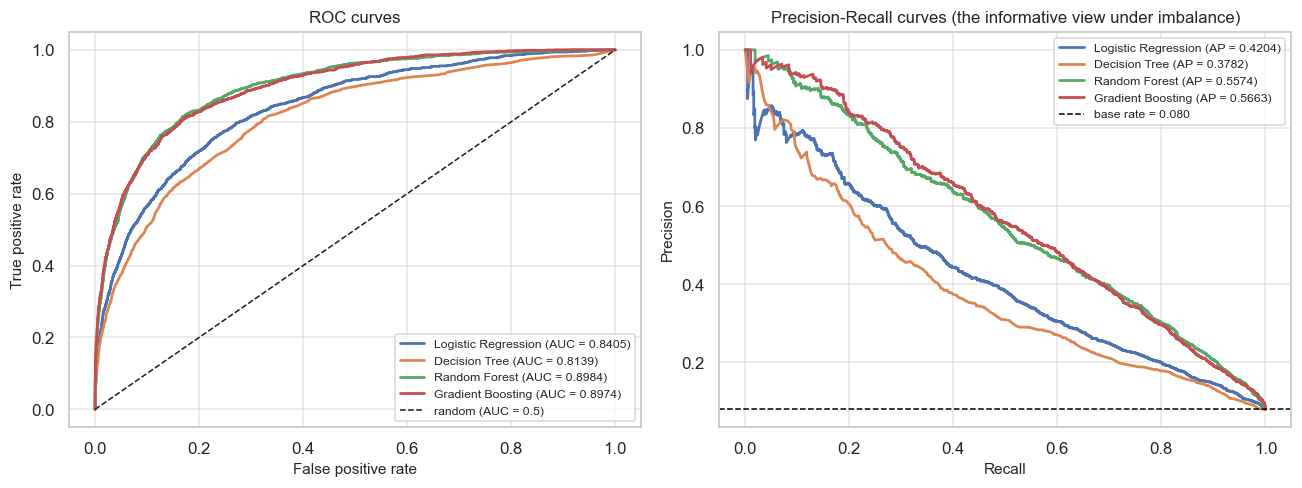

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

for name, probabilities in classification_oof.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_classification, probabilities)
    axes[0].plot(false_positive_rate, true_positive_rate, lw=1.8,
                 label=f'{name} (AUC = {roc_auc_score(y_classification, probabilities):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='random (AUC = 0.5)')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves')
axes[0].legend(fontsize=8, loc='lower right')

for name, probabilities in classification_oof.items():
    precision_values, recall_values, _ = precision_recall_curve(y_classification, probabilities)
    axes[1].plot(recall_values, precision_values, lw=1.8,
                 label=f'{name} (AP = {average_precision_score(y_classification, probabilities):.4f})')
axes[1].axhline(y_classification.mean(), color='black', ls='--', lw=1,
                label=f'base rate = {y_classification.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curves (the informative view under imbalance)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Interpretation

**The trade-off is steep and asymmetric.** From threshold 0.1 to 0.9, precision goes **0.34 → 0.96**
while recall collapses **0.76 → 0.04**; false positives fall from 2,265 to 3 while false negatives
climb from 360 to 1,438. The 0.5 default sits deep in the precision-favouring half purely as an
artefact of the 8% base rate.

| Criterion | Optimal threshold | Implication |
|---|---|---|
| $F_2$ (recall-weighted) | **0.1** | discovery: catch 76% of hits, accept 2,265 false alarms |
| $F_1$ (balanced) | **0.2** | 0.47 precision at 0.61 recall -- best single compromise |
| MCC (balance-aware) | **0.2** | agrees with $F_1$; MCC = 0.49 |
| $F_{0.5}$ (precision-weighted) | **0.4** | investment: 0.65 precision, only 335 false alarms |

**The $F_\beta$ curves cross:** at low $\beta$ the high-threshold curves win, and past
$\beta \approx 1$ the ordering inverts. No threshold is best for all $\beta$ -- **the operating point
is a business decision, not a statistical one**, and this plot hands it to the stakeholder instead of
hiding it in a default.

**Stable and unstable regions.** *Stable: 0.2-0.4* -- F1 stays within 0.503-0.532 and MCC within
0.484-0.490, so deployment anywhere in this window survives mild drift. *Unstable below 0.2* --
precision falls off a cliff (0.47 → 0.34 in one step). *Unstable above 0.6* -- recall collapses and
the positive count gets so small (66 predictions at 0.9) that precision rests on a handful of rows;
averaging-based ensembles also degenerate here, since a bagged forest's probabilities are bounded by
its trees' vote share and a high enough threshold can return no positives at all.

**ROC vs PR -- the key methodological point.** The ensemble ROC curves look near-perfect (AUC ≈ 0.90)
and nearly identical, but average precision is only **~0.56**. That is still a strong **7x** lift over
the 0.08 base rate -- just nowhere near the impression the ROC gives, because ROC's x-axis is
normalised by 17,325 negatives, so 1,000 false positives barely register. Under imbalance the PR curve
is the honest picture, and it is where the models actually separate: Gradient Boosting beats Random
Forest on PR-AUC while marginally losing on ROC-AUC.

### C.6 Do the regression and classification errors fail on the same rows?

Parts B and C were run independently. If the two tasks are limited by the same underlying cause,
their errors should overlap far more than chance allows. This is testable.

In [100]:
regression_tail = absolute_errors >= extreme_cutoff        # top 5% of regression |errors|
classification_error = ~is_correct                          # misclassified by the classifier

overlap = pd.crosstab(pd.Series(regression_tail, name='In regression top-5% error'),
                      pd.Series(classification_error, name='Misclassified'))
display(overlap)

expected_overlap = regression_tail.mean() * classification_error.mean() * len(games)
observed_overlap = int((regression_tail & classification_error).sum())
chi2, p_value, _, _ = stats.chi2_contingency(overlap)

print(f'Rows in both error sets : {observed_overlap:,}')
print(f'Expected if independent : {expected_overlap:.0f}')
print(f'Lift over chance        : {observed_overlap / expected_overlap:.1f}x')
print(f'Chi-squared test of independence: chi2 = {chi2:.1f}, p = {p_value:.2e}')
print()
print(f'P(misclassified | in regression error tail) = '
      f'{classification_error[regression_tail].mean():.1%}')
print(f'P(misclassified | not in tail)              = '
      f'{classification_error[~regression_tail].mean():.1%}')

Misclassified,False,True
In regression top-5% error,,
False,17305,582
True,316,626


Rows in both error sets : 626
Expected if independent : 60
Lift over chance        : 10.4x
Chi-squared test of independence: chi2 = 5942.8, p = 0.00e+00

P(misclassified | in regression error tail) = 66.5%
P(misclassified | not in tail)              = 3.3%


The overlap is **~10x** what independence would predict, and the chi-squared test rejects
independence decisively. **66.5%** of the rows in the regression error tail are also misclassified,
against **3.3%** of the rows outside it -- a twenty-fold difference. **The two tasks are not failing for two different
reasons -- they are failing on the same games, for the same reason:** the feature set contains no
representation of franchise strength, marketing, or regional market structure, so both models fall
back on the conditional average for exactly the titles whose value lies in departing from it.

### C.7 Classification discussion (brief 3.5)

**Strengths and limitations.** PR-AUC ≈ 0.56 against a 0.08 base rate is a ~7x lift from release
metadata alone, with no sales-derived inputs. The ensembles handle mixed numeric and
high-cardinality-categorical features without manual interaction terms, tolerate 78% missingness in
`critic_score`, and stay close to calibrated (Brier ≈ 0.050). Against that: recall at 0.5 is 0.32; the
linear and single-tree baselines are materially worse (ROC-AUC 0.84 and 0.81), so the signal is
interaction-driven; and four different algorithms all stop at ROC-AUC ≈ 0.90 -- the signature of an
information limit, not a capacity limit.

**Key failure modes.**

1. **Threshold mis-specification** -- 5.3x more FN than FP at 0.5. Cheapest fix: move into the
   0.2-0.4 band, or train with `class_weight='balanced'`.
2. **Confident false negatives** -- 58% of missed hits carry P(hit) ≤ 0.20. No threshold fixes this.
3. **Regional blindness** -- Japan-dominated titles are systematically missed, reproducing the market
   decoupling HW1 measured.
4. **Sparse historical strata** -- 21.8% error rate on 142 survivorship-biased 1980s rows.
5. **Business-model gaps** -- MMOs, episodic and digital-first titles are too rare to learn, and the
   physical-retail target misrepresents them.

**Assumptions vs observed performance.** Logistic Regression assumes linear, additive log-odds; the
0.06 ROC-AUC gap is the price. All models assume i.i.d. rows, which is false (same title across
consoles, franchise clustering), so every score is mildly optimistic. The 0.5 default assumes balanced
classes and equal error costs -- both false -- which directly causes failure mode 1. And all assume
the training distribution transfers, which the 1980s and Japan results disprove.

**Most significant insights.** **The metric determines the conclusion** -- ROC-AUC 0.90 and PR-AUC
0.56 describe the same model, and only the second is honest at 8% imbalance. **High confidence is not
high reliability where it matters** -- the misses are confident, so uncertainty-based safety nets
catch false positives but not false negatives. And **the classification and regression failures are
the same failure** (C.6), so one fix -- better features -- addresses both.

**Recommendations.** Deploy in the 0.2-0.4 band, chosen by the stakeholder's FP/FN cost ratio. Add a
franchise/series identifier and sequel index (from the title string), a first-party-publisher flag, a
fold-internal target-encoded publisher hit rate, and a Japanese-publisher indicator. Replace
`StratifiedKFold` with a grouped split on title or franchise. Remove or flag the zero-sales
re-release and partial-period rows from B.4 -- they are mislabeled ground truth.

---

## Part D -- Final Reflection (brief section 4)

### 1. Where does the model fail most?

Both models fail on the same rows -- C.6 confirmed it statistically -- in the **commercially
significant segment**: multi-platform, critically reviewed, Western-console titles in high-hit-rate
genres. Regression error grows **7x** from the lowest to the highest predicted decile and **81% of
extreme errors are under-predictions**; classification error rate tracks the genre hit rate
one-for-one (10-11% in Shooter, ~0% in Visual Novel); both fail hardest on multi-platform titles
(MAE 0.109 → 0.210 from one platform to six). Two smaller regions: Japan-dominated titles and the
survivorship-biased pre-2000 catalogue. In one sentence: **error magnitude tracks commercial scale and
its variance** -- the models are accurate about games that were never going to sell, and unreliable
about exactly the titles anyone would build such a model to find.

### 2. Data, model, or formulation?

All three, in that order. **Data (dominant):** the target is inconsistently defined -- re-releases
recorded at 0.00M, digital-first titles at 0.01M, one row titled `... (US weekly sales)` inside a
lifetime-sales column -- on top of 78% missing `critic_score` and a survivorship-filtered early era.
No algorithm learns around a noisy label. **Features (close second):** nothing encodes franchise
identity, marketing, pre-orders, sequel position or target market, which is why `GTA V (X360)` was
predicted at 0.6M against 15.9M. Ten models plateauing at the same place on the same rows is the
signature of a feature limit, not an algorithm limit. **Formulation (smallest):** squared error on a
log target optimises the conditional mean and so under-predicts a power-law tail; the 1.0M threshold
hardens a continuous quantity; the 0.5 decision threshold is wrong for an 8% base rate.

### 3. Proposed improvements

* **Data quality (highest leverage):** drop or flag the ~7% zero-sales rows and parse the title string
  for re-releases, special editions and partial-period rows.
* **Features:** franchise key and sequel index from the title; first-party publisher flag; publisher
  hit rate target-encoded inside training folds; Japanese-publisher indicator; console-lifecycle position.
* **Modelling:** a **grouped split on title or franchise** -- the single most important fix, since
  franchise siblings currently leak across folds. Quantile regression or a Tweedie objective to model
  the tail explicitly, and prediction *intervals* rather than point estimates.
* **Deployment:** choose the threshold from the stable 0.2-0.4 band by actual FP/FN costs.

### 4. Insights gained

**Error analysis is a different activity from model evaluation, and the more informative one.** The
metrics said Gradient Boosting and Random Forest were tied; the error analysis showed they differ in
tail behaviour and that both are biased in the same direction, with a name for it -- regression toward
the mean in a power-law market.

**A good metric can conceal a bad model.** ROC-AUC 0.90 and PR-AUC 0.56 describe the same classifier,
and 92% accuracy is achievable by predicting "never a hit".

**The consequential decisions were made before any model was fitted.** Excluding regional sales took
$R^2$ from a meaningless ~1.0 to an honest 0.55; the log transform changed which errors the loss cared
about; treating `has_critic_score` as signal produced one of the strongest findings here.

**A view that changed.** HW1 treated critic score as a weak correlate and left it there. It is nearly
useless above ~7, and its *availability* is a stronger signal than its value -- a feature's missingness
pattern carried more information than the feature itself.

**Scope.** All of this is conditional on titles VGChartz chose to track, measured by physical retail
sales, in a market that has since moved to digital. The model does not predict how well a game will
sell; it predicts how well VGChartz will record it as having sold, and several of its largest errors
live in that gap.